# 226 — How much of the answer key is reachable?

The QfO Pfam-region benchmark scores a domain call as a true positive when the called
interval reaches IoU ≥ 0.5 against the true domain (*boundary matched*). Notebook
[223](./223_mhc_platform_vs_ig_domain.ipynb) showed, on the MHC domains, that this is a
boundary test rather than a homology test. A full-length call against a domain of length `d`
inside a protein of length `L` scores exactly `d / L`, so the call can only pass when the
domain is at least half its protein, or when the target proteome supplies a protein carrying
that family with nothing else on it, from which a tight boundary can be inherited.

This notebook asks the same question of the whole answer key rather than of the MHC. The
truth set is the midi-plus run's 2,435 human domain instances on 998 query proteins (964
chromosome 6 proteins plus B2M, CD1A-E, MR1 and the KIR/LILR receptors) across 1,089 Pfam
families, searched against nine proteomes. That is 21,915 (instance, target species) pairs.
For how many of them can a true positive exist at all?

**Tools.** Sections 1 to 3 use no search result at all; they are arithmetic on the truth set
and the target Pfam annotations. Sections 4 and 5 read the sixteen focus arms of the run: the
nine comparison tools (phmmer, jackhmmer, MMseqs2, MMseqs2 iterative, HHblits, Foldseek,
ProstT5, Reseek, Folddisco) and seven kmerseek arms (hp_pbotc_1st_ed2 k=19, 21, 24;
hp_thomas_dill2 k=26; dayhoff6 k=12; funcgroups8 k=12; protein20 k=10). Where a figure names
kmerseek it names the alphabet and k.

Every number here is the **pfam** truth set only. `all_domain_metrics.parquet` stacks three
truth sets (`pfam`, `pfamn`, `swissprot`) in one file with rows duplicated across them, and
the `swissprot` slice is unusable for cross-species work: Swiss-Prot has 28 reviewed *Ciona*
entries in total, so its coverage ranges 540-fold across the nine species, and its `pfam_id`
column holds a feature type rather than a Pfam family. Every read of that file below filters
`truth_set == "pfam"` first. The truth mirror and the target domain maps are pfam-only
already.

Siblings: [220](./220_mhc_region_map_and_coverage.ipynb) maps the region,
[221](./221_mhc_cross_species_detection_depth.ipynb) walks it out to 2,000 Mya,
[223](./223_mhc_platform_vs_ig_domain.ipynb) found the mechanism on the MHC domains.


## 1. The length fraction of the answer key

`length_fraction = (domain_end - domain_start + 1) / protein_length` is the IoU a
full-length call would score. It needs no target information at all. Condition 1 is
`length_fraction ≥ 0.5`.

Run: QfO Pfam-region benchmark, midi-plus (2026-09-01 to 09-02, 4,723 tasks). 998 human queries: 964 chromosome 6 proteins plus B2M, CD1A-E, MR1 and 27 KIR/LILR receptors. Targets: mouse, chicken, zebrafish, ciona, fly, worm, yeast, Arabidopsis and E. coli, all scored against Pfam; Botryllus schlosseri searched but unscored.

truth instances: 2435 on 998 human query proteins
Pfam families:   1089
(instance, species) pairs: 21915

domain length / protein length / length fraction:
shape: (6, 4)
┌───────────┬────────────┬─────────────┬─────────────────┐
│ statistic ┆ domain_len ┆ protein_len ┆ length_fraction │
│ ---       ┆ ---        ┆ ---         ┆ ---             │
│ str       ┆ f64        ┆ f64         ┆ f64             │
╞═══════════╪════════════╪═════════════╪═════════════════╡
│ min       ┆ 18.0       ┆ 24.0        ┆ 0.0052          │
│ 25%       ┆ 55.0       ┆ 376.0       ┆ 0.0553          │
│ median    ┆ 89.0       ┆ 598.0       ┆ 0.1415          │
│ 75%       ┆ 150.0      ┆ 119

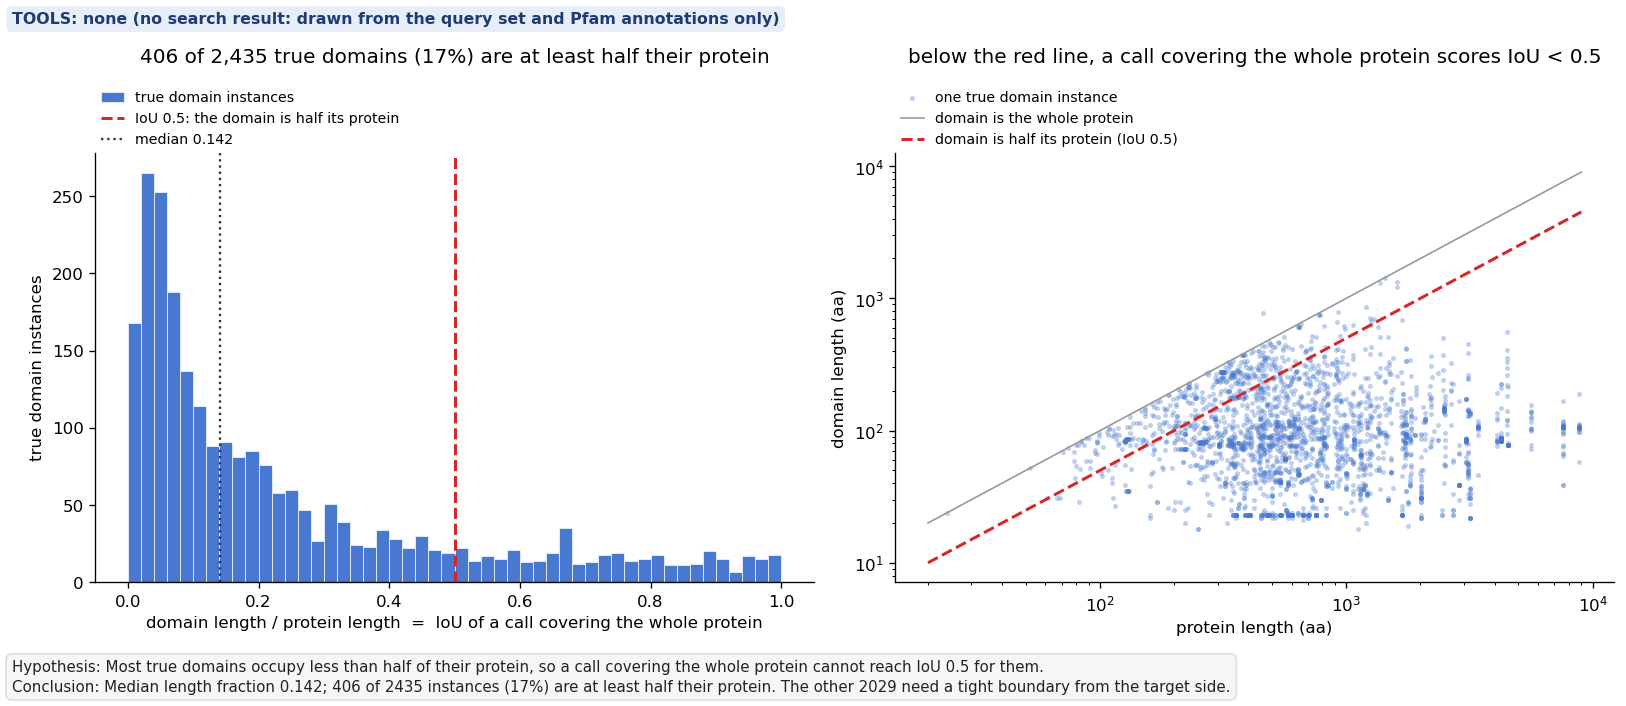

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

TRUTH = (
    mu.load_human_truth()
    .with_columns(domain_len=pl.col("domain_end") - pl.col("domain_start") + 1)
    .with_columns(
        length_fraction=(pl.col("domain_end") - pl.col("domain_start") + 1)
        / pl.col("protein_length")
    )
)
N_TRUTH = TRUTH.height
N_PAIRS = N_TRUTH * len(mu.SPECIES_ORDER)

print(mu.RUN_SUMMARY)
print(
    f"\ntruth instances: {N_TRUTH} on {TRUTH['accession'].n_unique()} human query proteins"
)
print(f"Pfam families:   {TRUTH['pfam_id'].n_unique()}")
print(f"(instance, species) pairs: {N_PAIRS}")
print()
print("domain length / protein length / length fraction:")
desc = pl.DataFrame(
    {
        "statistic": ["min", "25%", "median", "75%", "max", "mean"],
        "domain_len": [
            float(TRUTH["domain_len"].min()),
            float(TRUTH["domain_len"].quantile(0.25)),
            float(TRUTH["domain_len"].median()),
            float(TRUTH["domain_len"].quantile(0.75)),
            float(TRUTH["domain_len"].max()),
            round(float(TRUTH["domain_len"].mean()), 1),
        ],
        "protein_len": [
            float(TRUTH["protein_length"].min()),
            float(TRUTH["protein_length"].quantile(0.25)),
            float(TRUTH["protein_length"].median()),
            float(TRUTH["protein_length"].quantile(0.75)),
            float(TRUTH["protein_length"].max()),
            round(float(TRUTH["protein_length"].mean()), 1),
        ],
        "length_fraction": [
            round(float(TRUTH["length_fraction"].min()), 4),
            round(float(TRUTH["length_fraction"].quantile(0.25)), 4),
            round(float(TRUTH["length_fraction"].median()), 4),
            round(float(TRUTH["length_fraction"].quantile(0.75)), 4),
            round(float(TRUTH["length_fraction"].max()), 4),
            round(float(TRUTH["length_fraction"].mean()), 4),
        ],
    }
)
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(desc)

EDGES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.001]
band_rows = []
for lo, hi in zip(EDGES[:-1], EDGES[1:]):
    s = TRUTH.filter(
        (pl.col("length_fraction") >= lo) & (pl.col("length_fraction") < hi)
    )
    band_rows.append(
        {
            "band": f"{lo:.2f}-{hi:.2f}",
            "n": s.height,
            "frac": round(s.height / N_TRUTH, 4),
            "median_domain_len": (
                None if s.height == 0 else int(s["domain_len"].median())
            ),
            "median_protein_len": (
                None if s.height == 0 else int(s["protein_length"].median())
            ),
            "clears_iou_0.5": lo >= 0.5,
        }
    )
bands = pl.DataFrame(band_rows)
n_cond1 = int((TRUTH["length_fraction"] >= 0.5).sum())
print()
print("length fraction, banded:")
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(bands)
print()
print(
    f"condition 1 (length_fraction >= 0.5): {n_cond1} of {N_TRUTH} "
    f"= {n_cond1 / N_TRUTH:.1%} of the answer key"
)
print(
    f"the other {N_TRUTH - n_cond1} instances need a tight boundary from somewhere else"
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
ax = axes[0]
ax.hist(
    TRUTH["length_fraction"].to_numpy(),
    bins=np.linspace(0, 1, 51),
    color="#4878CF",
    edgecolor="white",
    linewidth=0.4,
    label="true domain instances",
)
ax.axvline(0.5, color="#D62728", lw=1.8, ls="--", label="IoU 0.5: the domain is half its protein")
ax.axvline(
    TRUTH["length_fraction"].median(),
    color="#333333",
    lw=1.4,
    ls=":",
    label=f"median {TRUTH['length_fraction'].median():.3f}",
)
ax.set_xlabel("domain length / protein length  =  IoU of a call covering the whole protein")
ax.set_ylabel("true domain instances")
ax.set_title(
    f"{n_cond1} of {N_TRUTH:,} true domains ({n_cond1 / N_TRUTH:.0%}) are at least half their protein"
)
mu.legend_above(ax, ncol=1)

ax = axes[1]
ax.scatter(
    TRUTH["protein_length"].to_numpy(),
    TRUTH["domain_len"].to_numpy(),
    s=9,
    alpha=0.35,
    color="#4878CF",
    linewidth=0,
    label="one true domain instance",
)
xs = np.array([20, 9000])
ax.plot(xs, xs, color="#999999", lw=1.0, ls="-", label="domain is the whole protein")
ax.plot(xs, 0.5 * xs, color="#D62728", lw=1.8, ls="--", label="domain is half its protein (IoU 0.5)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("protein length (aa)")
ax.set_ylabel("domain length (aa)")
ax.set_title("below the red line, a call covering the whole protein scores IoU < 0.5")
mu.legend_above(ax, ncol=1)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "226_length_fraction.png",
    tools=mu.NO_TOOL,
    hypothesis="Most true domains occupy less than half of their protein, so a call covering the whole protein cannot reach IoU 0.5 for them.",
    conclusion=(
        f"Median length fraction {TRUTH['length_fraction'].median():.3f}; {n_cond1} of {N_TRUTH} instances "
        f"({n_cond1 / N_TRUTH:.0%}) are at least half their protein. The other {N_TRUTH - n_cond1} need a tight boundary from the target side."
    ),
)


## 2. Single-domain targets: where a tight boundary can come from

The pipeline transfers every Pfam family annotated on a matched target protein onto the
aligned query interval. If every target protein carrying family F also carries something
else, the transferred interval tends to span both, and the call overruns the domain.
Condition 2 asks whether the target proteome holds at least one protein whose *only* Pfam
family is F.

The table also carries `max_target_length_fraction`, the largest fraction of a target
protein that one instance of the family occupies. It is not part of the two-condition rule
but it is used in §4, where it turns out to be the better predictor.

Per target proteome, over the 1_089 families in the answer key:
shape: (9, 8)
┌─────────────┬────────────┬──────────────────┬────────────────────┬──────────────────────────┬──────────────────────────┬──────────────┬────────────────┐
│ species     ┆ n_families ┆ families_present ┆ families_with_solo ┆ families_present_no_solo ┆ median_solo_when_present ┆ frac_present ┆ frac_with_solo │
│ ---         ┆ ---        ┆ ---              ┆ ---                ┆ ---                      ┆ ---                      ┆ ---          ┆ ---            │
│ str         ┆ u32        ┆ u32              ┆ u32                ┆ u32                      ┆ f64                      ┆ f64          ┆ f64            │
╞═════════════╪════════════╪══════════════════╪════════════════════╪══════════════════════════╪══════════════════════════╪══════════════╪════════════════╡
│ mouse       ┆ 1089       ┆ 1076             ┆ 539                ┆ 537                      ┆ 1.0                      ┆ 0.988        ┆ 0.495    

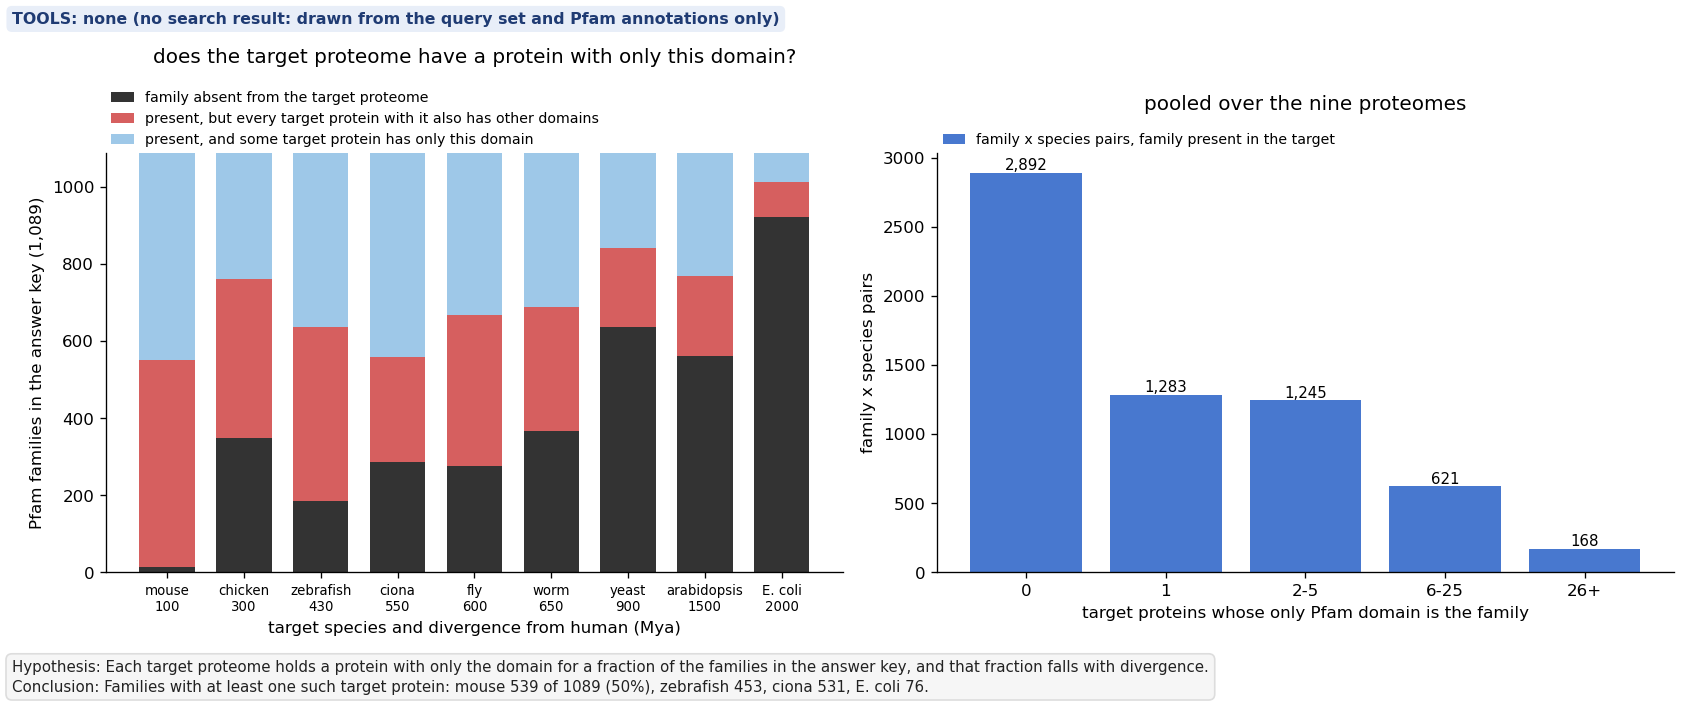

In [2]:
FAMS = sorted(TRUTH["pfam_id"].unique().to_list())

avail_parts = []
for sp in mu.SPECIES_ORDER:
    dm = mu.load_target_domain_map(sp).with_columns(
        tlf=(pl.col("domain_end") - pl.col("domain_start") + 1)
        / pl.col("protein_length")
    )
    n_fam_on_protein = dm.group_by("accession").agg(
        pl.col("pfam_id").n_unique().alias("n_fam")
    )
    dm = dm.join(n_fam_on_protein, on="accession", how="left")
    agg = dm.group_by("pfam_id").agg(
        n_target_proteins=pl.col("accession").n_unique(),
        n_solo_targets=pl.col("accession").filter(pl.col("n_fam") == 1).n_unique(),
        max_target_length_fraction=pl.col("tlf").max(),
    )
    # Zero-fill across every family in the answer key: a family with no row here is a zero,
    # not a missing value.
    part = (
        pl.DataFrame({"pfam_id": FAMS})
        .join(agg, on="pfam_id", how="left")
        .with_columns(
            pl.col("n_target_proteins").fill_null(0),
            pl.col("n_solo_targets").fill_null(0),
            pl.col("max_target_length_fraction").fill_null(0.0),
            species=pl.lit(sp),
        )
    )
    avail_parts.append(part)
AVAIL = pl.concat(avail_parts)

per_species = (
    AVAIL.group_by("species")
    .agg(
        n_families=pl.len(),
        families_present=(pl.col("n_target_proteins") > 0).sum(),
        families_with_solo=(pl.col("n_solo_targets") > 0).sum(),
        families_present_no_solo=(
            (pl.col("n_target_proteins") > 0) & (pl.col("n_solo_targets") == 0)
        ).sum(),
        median_solo_when_present=pl.col("n_solo_targets")
        .filter(pl.col("n_target_proteins") > 0)
        .median(),
    )
    .with_columns(
        frac_present=(pl.col("families_present") / pl.col("n_families")).round(3),
        frac_with_solo=(pl.col("families_with_solo") / pl.col("n_families")).round(3),
    )
    .sort("species")
)
order = pl.DataFrame({"species": mu.SPECIES_ORDER, "_o": range(len(mu.SPECIES_ORDER))})
per_species = per_species.join(order, on="species").sort("_o").drop("_o")
print(f"Per target proteome, over the {len(FAMS):_} families in the answer key:")
with pl.Config(tbl_rows=12, tbl_width_chars=190):
    print(per_species)
print()
print("Distribution of n_solo_targets among families that are present at all:")
solo_present = AVAIL.filter(pl.col("n_target_proteins") > 0)
solo_bands = pl.DataFrame(
    {
        "n_solo_targets": ["0", "1", "2-5", "6-25", "26+"],
        "n_family_species_cells": [
            solo_present.filter(pl.col("n_solo_targets") == 0).height,
            solo_present.filter(pl.col("n_solo_targets") == 1).height,
            solo_present.filter(pl.col("n_solo_targets").is_between(2, 5)).height,
            solo_present.filter(pl.col("n_solo_targets").is_between(6, 25)).height,
            solo_present.filter(pl.col("n_solo_targets") >= 26).height,
        ],
    }
)
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(solo_bands)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
x = np.arange(len(mu.SPECIES_ORDER))
present = np.array([
    per_species.filter(pl.col("species") == s)["families_present"][0]
    for s in mu.SPECIES_ORDER
])
withsolo = np.array([
    per_species.filter(pl.col("species") == s)["families_with_solo"][0]
    for s in mu.SPECIES_ORDER
])
absent = len(FAMS) - present
no_solo = present - withsolo
ax = axes[0]
ax.bar(x, absent, color=mu.CENSUS_CLASS_COLORS["family absent from target"], width=0.72,
       label="family absent from the target proteome")
ax.bar(x, no_solo, bottom=absent, color=mu.CENSUS_CLASS_COLORS["present, inaccessible by transfer"], width=0.72,
       label="present, but every target protein with it also has other domains")
ax.bar(x, withsolo, bottom=absent + no_solo, color=mu.CENSUS_CLASS_COLORS["reachable via single-domain target"], width=0.72,
       label="present, and some target protein has only this domain")
ax.set_xticks(x)
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_xlabel("target species and divergence from human (Mya)")
ax.set_ylabel(f"Pfam families in the answer key ({len(FAMS):,})")
ax.set_ylim(0, len(FAMS))
ax.set_title("does the target proteome have a protein with only this domain?")
mu.legend_above(ax, ncol=1)

ax = axes[1]
vals = solo_bands["n_family_species_cells"].to_list()
ax.bar(range(len(vals)), vals, color="#4878CF", label="family x species pairs, family present in the target")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(solo_bands["n_solo_targets"].to_list())
ax.set_xlabel("target proteins whose only Pfam domain is the family")
ax.set_ylabel("family x species pairs")
ax.set_title("pooled over the nine proteomes")
mu.legend_above(ax, ncol=1)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
ps = {r["species"]: r for r in per_species.iter_rows(named=True)}
mu.finish_figure(
    fig,
    FIG_DIR / "226_single_domain_targets.png",
    tools=mu.NO_TOOL,
    hypothesis="Each target proteome holds a protein with only the domain for a fraction of the families in the answer key, and that fraction falls with divergence.",
    conclusion=(
        f"Families with at least one such target protein: mouse {ps['mouse']['families_with_solo']} of {len(FAMS)} "
        f"({ps['mouse']['frac_with_solo']:.0%}), zebrafish {ps['zebrafish']['families_with_solo']}, ciona {ps['ciona']['families_with_solo']}, "
        f"E. coli {ps['ecoli']['families_with_solo']}."
    ),
)


## 3. The census

Every (instance, species) pair is put in one of five classes.

- **family absent from target**: no target protein carries the family, so no transfer can
  ever produce it. This is a hard floor, not a heuristic.
- **present, inaccessible by transfer**: the family is in the target proteome, but
  neither situation that hands a tool a passing call applies. The domain is under half its
  query protein, so a call covering the whole protein cannot reach IoU 0.5, and no target
  protein consists of this family alone, so copying a target protein's coordinates onto
  the query gives an interval that is too wide. A tool can still match the boundary here,
  but only by an alignment that stops at the domain on its own; §4.2 finds some arm does
  so for 60% of these cells.
- **reachable via length fraction**: condition 1 only.
- **reachable via single-domain target**: condition 2 only.
- **reachable via both**.

Census over 21,915 (instance, species) pairs:
shape: (5, 3)
┌────────────────────────────────────┬──────┬────────┐
│ reach_class                        ┆ len  ┆ frac   │
│ ---                                ┆ ---  ┆ ---    │
│ str                                ┆ u32  ┆ f64    │
╞════════════════════════════════════╪══════╪════════╡
│ family absent from target          ┆ 7043 ┆ 0.3214 │
│ present, inaccessible by transfer  ┆ 4760 ┆ 0.2172 │
│ reachable via length fraction      ┆ 227  ┆ 0.0104 │
│ reachable via single-domain target ┆ 7759 ┆ 0.354  │
│ reachable via both                 ┆ 2126 ┆ 0.097  │
└────────────────────────────────────┴──────┴────────┘

guaranteed miss, family absent:                  7043  32.1%
predicted miss, inaccessible by transfer:        4760  21.7%
total not predicted reachable:                  11803  53.9%
predicted reachable:                            10112  46.1%

Per species (each row sums to 2,435):
shape: (9, 7)
┌─────────────┬──────────────────────

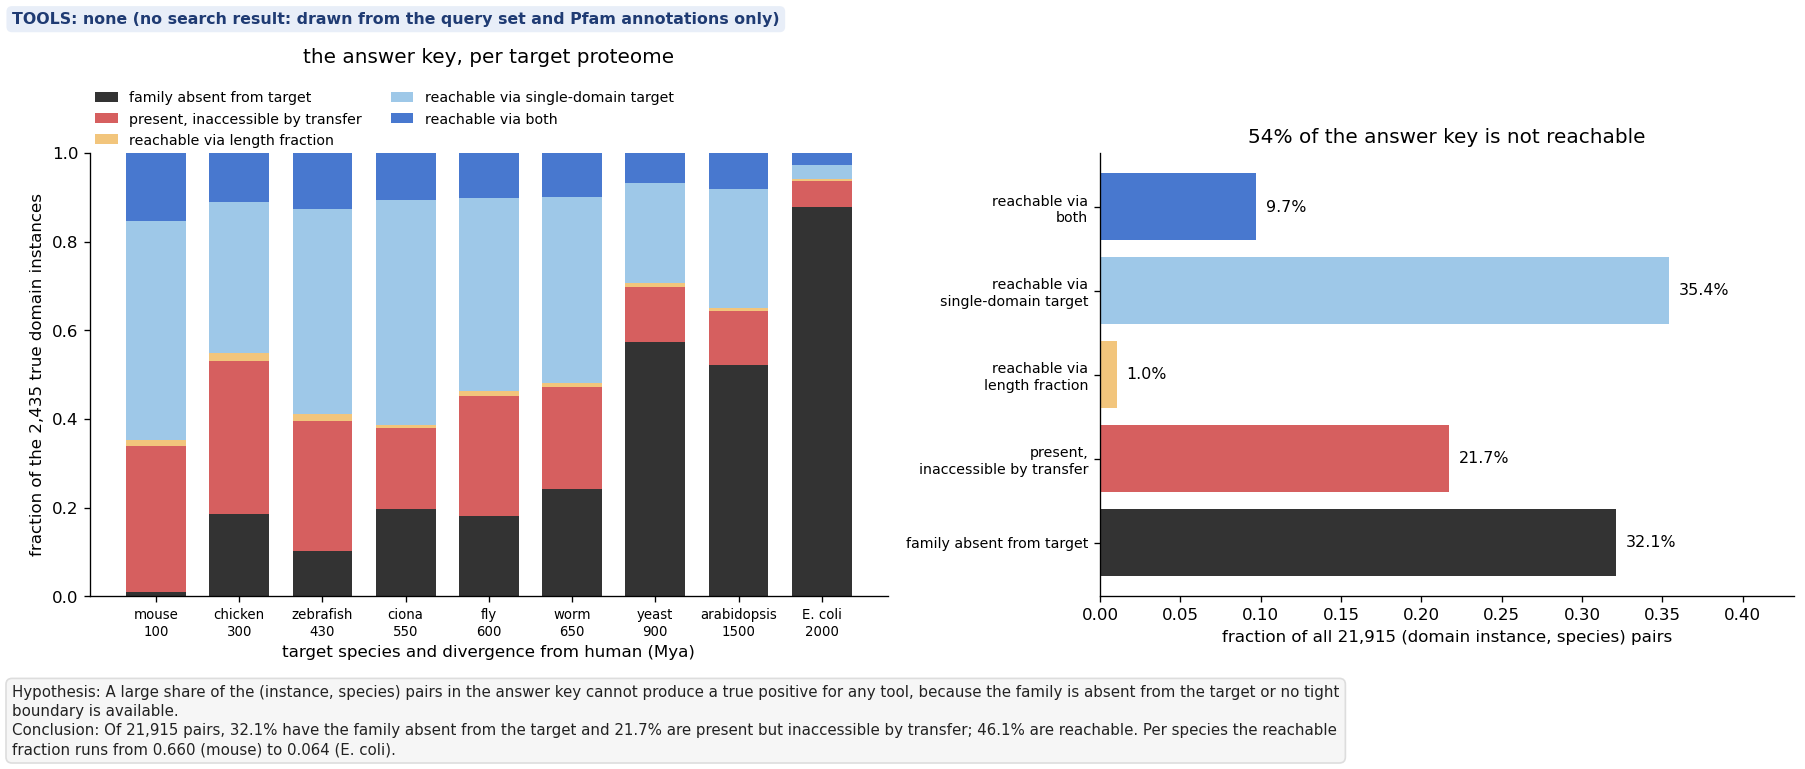

In [3]:
CENSUS = TRUTH.join(AVAIL, on="pfam_id", how="left").with_columns(
    present=pl.col("n_target_proteins") > 0,
    cond1=pl.col("length_fraction") >= 0.5,
    cond2=pl.col("n_solo_targets") > 0,
)
CENSUS = CENSUS.with_columns(
    reach_class=pl.when(~pl.col("present"))
    .then(pl.lit("family absent from target"))
    .when(pl.col("cond1") & pl.col("cond2"))
    .then(pl.lit("reachable via both"))
    .when(pl.col("cond1"))
    .then(pl.lit("reachable via length fraction"))
    .when(pl.col("cond2"))
    .then(pl.lit("reachable via single-domain target"))
    .otherwise(pl.lit("present, inaccessible by transfer")),
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2")),
)
assert CENSUS.height == N_PAIRS, CENSUS.height

CLASS_ORDER = [
    "family absent from target",
    "present, inaccessible by transfer",
    "reachable via length fraction",
    "reachable via single-domain target",
    "reachable via both",
]
CLASS_COLORS = {
    "family absent from target": "#333333",
    "present, inaccessible by transfer": "#D65F5F",
    "reachable via length fraction": "#F2C57C",
    "reachable via single-domain target": "#9EC8E8",
    "reachable via both": "#4878CF",
}

overall = (
    CENSUS.group_by("reach_class")
    .len()
    .with_columns(frac=(pl.col("len") / N_PAIRS).round(4))
)
overall = (
    pl.DataFrame({"reach_class": CLASS_ORDER})
    .join(overall, on="reach_class", how="left")
    .with_columns(pl.col("len").fill_null(0), pl.col("frac").fill_null(0.0))
)
print(f"Census over {N_PAIRS:,} (instance, species) pairs:")
with pl.Config(tbl_rows=10, tbl_width_chars=140, fmt_str_lengths=45):
    print(overall)

n_absent = int(CENSUS.filter(~pl.col("present")).height)
n_unreach = int(CENSUS.filter(pl.col("present") & ~pl.col("reachable")).height)
n_reach = int(CENSUS["reachable"].sum())
print()
print(
    f"guaranteed miss, family absent:                {n_absent:6d}  {n_absent / N_PAIRS:.1%}"
)
print(
    f"predicted miss, inaccessible by transfer:      {n_unreach:6d}  {n_unreach / N_PAIRS:.1%}"
)
print(
    f"total not predicted reachable:                 {n_absent + n_unreach:6d}"
    f"  {(n_absent + n_unreach) / N_PAIRS:.1%}"
)
print(
    f"predicted reachable:                           {n_reach:6d}  {n_reach / N_PAIRS:.1%}"
)

per_sp = (
    CENSUS.group_by("species", "reach_class")
    .len()
    .pivot(on="reach_class", index="species", values="len")
)
for c in CLASS_ORDER:
    if c not in per_sp.columns:
        per_sp = per_sp.with_columns(pl.lit(0).alias(c))
per_sp = (
    per_sp.fill_null(0)
    .select(["species"] + CLASS_ORDER)
    .with_columns(
        frac_reachable=(
            (
                pl.col("reachable via both")
                + pl.col("reachable via length fraction")
                + pl.col("reachable via single-domain target")
            )
            / N_TRUTH
        ).round(3)
    )
    .join(order, on="species")
    .sort("_o")
    .drop("_o")
)
print()
print(f"Per species (each row sums to {N_TRUTH:,}):")
with pl.Config(tbl_rows=12, tbl_width_chars=220, fmt_str_lengths=40):
    print(per_sp)

# Cross-check against the pipeline's own presence-based denominator, pfam slice only.
metrics = pl.read_parquet(mu.ALL_DOMAIN_METRICS).filter(
    (pl.col("truth_set") == "pfam")
    & (pl.col("stratum_axis") == "all")
    & (pl.col("dedup_transfers") == False)
    & (pl.col("split") == "all")
    & (pl.col("species") != "all")
    & (pl.col("tool") != "hmmscan")
)
pipe_present = (
    metrics.group_by("species")
    .agg(pipeline_n_reachable=pl.col("n_reachable_instances").max())
    .join(
        per_sp.select(
            "species", mine=pl.lit(N_TRUTH) - pl.col("family absent from target")
        ),
        on="species",
        how="inner",
    )
    .with_columns(agrees=pl.col("pipeline_n_reachable") == pl.col("mine"))
)
print()
print(
    "Cross-check: the pipeline's own reachability denominator counts family presence only."
)
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(pipe_present.sort("species"))

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5.4), gridspec_kw={"width_ratios": [1.15, 1]}
)
ax = axes[0]
bottom = np.zeros(len(mu.SPECIES_ORDER))
for c in CLASS_ORDER:
    vals = (
        np.array(
            [per_sp.filter(pl.col("species") == s)[c][0] for s in mu.SPECIES_ORDER],
            dtype=float,
        )
        / N_TRUTH
    )
    ax.bar(
        np.arange(len(mu.SPECIES_ORDER)),
        vals,
        bottom=bottom,
        color=CLASS_COLORS[c],
        label=c,
        width=0.72,
    )
    bottom += vals
ax.set_xticks(np.arange(len(mu.SPECIES_ORDER)))
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_xlabel("target species and divergence from human (Mya)")
ax.set_ylabel(f"fraction of the {N_TRUTH:,} true domain instances")
ax.set_ylim(0, 1)
ax.set_title("the answer key, per target proteome")
mu.legend_above(ax, ncol=2)

ax = axes[1]
vals = [overall.filter(pl.col("reach_class") == c)["frac"][0] for c in CLASS_ORDER]
ax.barh(
    range(len(CLASS_ORDER)),
    vals,
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
)
for i, v in enumerate(vals):
    ax.text(v + 0.006, i, f"{v:.1%}", va="center", fontsize=9.5)
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_yticklabels(
    [c.replace(", ", ",\n").replace(" via ", " via\n") for c in CLASS_ORDER],
    fontsize=8.5,
)
ax.set_xlim(0, max(vals) * 1.22)
ax.set_xlabel(f"fraction of all {N_PAIRS:,} (domain instance, species) pairs")
ax.set_title(
    f"{(n_absent + n_unreach) / N_PAIRS:.0%} of the answer key is not reachable"
)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "226_census.png",
    tools=mu.NO_TOOL,
    hypothesis="A large share of the (instance, species) pairs in the answer key cannot produce a true positive for any tool, because the family is absent from the target or no tight boundary is available.",
    conclusion=(
        f"Of {N_PAIRS:,} pairs, {n_absent / N_PAIRS:.1%} have the family absent from the target and "
        f"{n_unreach / N_PAIRS:.1%} are present but inaccessible by transfer; {n_reach / N_PAIRS:.1%} are reachable. "
        f"Per species the reachable fraction runs from {per_sp['frac_reachable'].max():.3f} (mouse) to {per_sp['frac_reachable'].min():.3f} (E. coli)."
    ),
)


## 4. Does it predict what actually happened?

The census is arithmetic about the truth set and the target annotations. Whether it predicts
outcomes is a separate question, and the run answers it locally: `chr6_calls_focus` holds
every raw call for all 998 query proteins across nine species and sixteen arms (nine
comparison tools, seven kmerseek arms), which is the whole answer key rather than a subset.

The call table identifies a call by (query protein, Pfam family) and does not say which
*instance* of a repeated family it matched, so this section works at
(protein, family, species) level, protein-family pairs times nine species. An instance-level
and a pair-level denominator differ by the instances that are repeats of a family already on
the same protein; the counts are printed below.

§4.1 does the MHC subset, §4.2 the whole answer key, §4.3 the covariates.

MHC subset: 25 curated genes, the ten headline arms (nine comparison tools + kmerseek hp_pbotc_1st_ed2 k=19).
  468 (gene, family) pairs x 9 species, 10 arms
shape: (2, 4)
┌───────────┬─────────┬───────────────────────┬──────────────┐
│ reachable ┆ n_cells ┆ boundary_matched_rate ┆ covered_rate │
│ ---       ┆ ---     ┆ ---                   ┆ ---          │
│ bool      ┆ u32     ┆ f64                   ┆ f64          │
╞═══════════╪═════════╪═══════════════════════╪══════════════╡
│ true      ┆ 1220    ┆ 0.7533                ┆ 0.7861       │
│ false     ┆ 3460    ┆ 0.0645                ┆ 0.1882       │
└───────────┴─────────┴───────────────────────┴──────────────┘
shape: (2, 3)
┌───────────┬─────┬─────────────────────────────────┐
│ reachable ┆ n   ┆ ever_boundary_matched_by_some_… │
│ ---       ┆ --- ┆ ---                             │
│ bool      ┆ u32 ┆ f64                             │
╞═══════════╪═════╪═════════════════════════════════╡
│ true      ┆ 122 ┆ 0.9836              

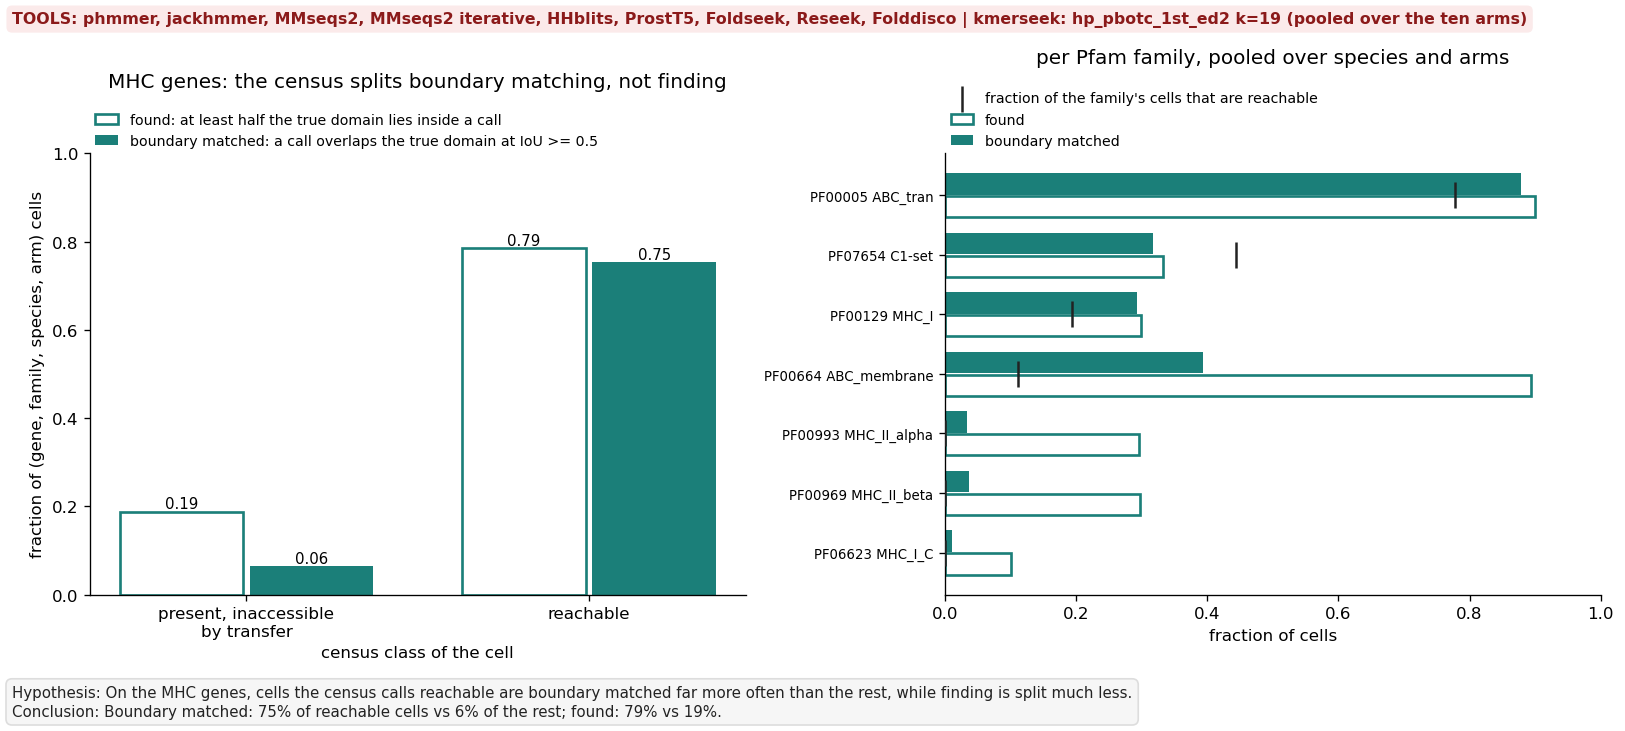

In [4]:
# --- 4.1 the 25 curated MHC genes (24 chr6 + B2M), from the collapsed per-domain table ---
core = mu.load_query_gene_map().filter(pl.col("mhc_class").is_not_null())
mhc_truth = TRUTH.rename({"accession": "query_acc"}).join(
    core.select(query_acc="accession", hgnc_symbol="hgnc_symbol"),
    on="query_acc",
    how="inner",
)
mhc_pairs = (
    mhc_truth.group_by("query_acc", "hgnc_symbol", "pfam_id")
    .agg(max_lf=pl.col("length_fraction").max())
    .join(AVAIL, on="pfam_id", how="left")
    .with_columns(
        present=pl.col("n_target_proteins") > 0,
        cond1=pl.col("max_lf") >= 0.5,
        cond2=pl.col("n_solo_targets") > 0,
    )
)
mhc_pairs = mhc_pairs.with_columns(
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2"))
)

dl = (
    mu.load_domain_level()
    .filter(pl.col("truth_set") == "pfam")
    .with_columns(arm=pl.col("tool") + "." + pl.col("variant"))
)
MHC_ARMS = [
    "hmmer3_phmmer.default",
    "hmmer3_jackhmmer.n3",
    "hhblits.single_seq",
    "mmseqs2_seqseq.s7",
    "mmseqs2_iterative.s7",
    "foldseek.3di_aa",
    "reseek.verysensitive",
    "prostt5.3di_from_seq",
    "folddisco.motif",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
]
dl = dl.filter(pl.col("arm").is_in(MHC_ARMS))
mhc_arms = dl.select("tool", "variant").unique()
mhc_grid = (
    mhc_pairs.join(mhc_arms, how="cross")
    .join(
        dl.select(
            "query_acc",
            "pfam_id",
            "species",
            "tool",
            "variant",
            "found",
            "best_iou",
            "best_cover",
        ),
        on=["query_acc", "pfam_id", "species", "tool", "variant"],
        how="left",
    )
    .with_columns(
        pl.col("found").fill_null(False),
        pl.col("best_iou").fill_null(0.0),
        pl.col("best_cover").fill_null(0.0),
    )
)
mhc_tab = (
    mhc_grid.group_by("reachable")
    .agg(
        n_cells=pl.len(),
        boundary_matched_rate=pl.col("found").mean().round(4),
        covered_rate=(pl.col("best_cover") >= 0.5).mean().round(4),
    )
    .sort("reachable", descending=True)
)
mhc_ever = (
    mhc_grid.group_by("query_acc", "hgnc_symbol", "pfam_id", "species", "reachable")
    .agg(ever=pl.col("found").max())
    .group_by("reachable")
    .agg(n=pl.len(), ever_boundary_matched_by_some_arm=pl.col("ever").mean().round(4))
    .sort("reachable", descending=True)
)
print(f"MHC subset: {core.height} curated genes, the ten headline arms (nine comparison tools + kmerseek hp_pbotc_1st_ed2 k=19).")
print(
    f"  {mhc_pairs.height} (gene, family) pairs x 9 species, "
    f"{mhc_grid.select('tool', 'variant').n_unique()} arms"
)
with pl.Config(tbl_rows=10, tbl_width_chars=140):
    print(mhc_tab)
    print(mhc_ever)

by_fam = (
    mhc_grid.group_by("pfam_id")
    .agg(
        reachable_frac=pl.col("reachable").mean().round(3),
        boundary_matched=pl.col("found").mean().round(3),
        covered=(pl.col("best_cover") >= 0.5).mean().round(3),
        n=pl.len(),
    )
    .filter(pl.col("n") >= 30)
    .sort("reachable_frac", descending=True)
)
print()
print("MHC subset, per Pfam family (families with >= 30 arm-species cells):")
with pl.Config(tbl_rows=40, tbl_width_chars=150):
    print(by_fam)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
ax = axes[0]
lab = ["present, inaccessible\nby transfer", "reachable"]
d = [
    mhc_tab.filter(~pl.col("reachable"))["boundary_matched_rate"][0],
    mhc_tab.filter(pl.col("reachable"))["boundary_matched_rate"][0],
]
c = [
    mhc_tab.filter(~pl.col("reachable"))["covered_rate"][0],
    mhc_tab.filter(pl.col("reachable"))["covered_rate"][0],
]
xx = np.arange(2)
ax.bar(xx - 0.19, c, 0.36, label=mu.FOUND_LABEL, **mu.outcome_style("found"))
ax.bar(xx + 0.19, d, 0.36, label=mu.BOUNDARY_LABEL, **mu.outcome_style("boundary matched"))
for i, (cv, dv) in enumerate(zip(c, d)):
    ax.text(i - 0.19, cv, f"{cv:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.19, dv, f"{dv:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xx)
ax.set_xticklabels(lab)
ax.set_xlabel("census class of the cell")
ax.set_ylabel("fraction of (gene, family, species, arm) cells")
ax.set_ylim(0, 1)
ax.set_title("MHC genes: the census splits boundary matching, not finding")
mu.legend_above(ax, ncol=1)

ax = axes[1]
b = by_fam.sort("reachable_frac")
yy = np.arange(b.height)
ax.barh(yy - 0.19, b["covered"], 0.36, label="found", **mu.outcome_style("found"))
ax.barh(yy + 0.19, b["boundary_matched"], 0.36, label="boundary matched", **mu.outcome_style("boundary matched"))
ax.scatter(
    b["reachable_frac"],
    yy,
    marker="|",
    s=260,
    color="#222222",
    zorder=5,
    label="fraction of the family's cells that are reachable",
)
names = mu.pfam_label(b["pfam_id"].to_list())
ax.set_yticks(yy)
ax.set_yticklabels([names[p] for p in b["pfam_id"]], fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("fraction of cells")
ax.set_title("per Pfam family, pooled over species and arms")
mu.legend_above(ax, ncol=1)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mt = {bool(r["reachable"]): r for r in mhc_tab.iter_rows(named=True)}
mu.finish_figure(
    fig,
    FIG_DIR / "226_mhc_subset_check.png",
    tools=mu.tools_text(mu.COMPARISON_TOOLS, kmerseek=[mu.BEST_KMERSEEK], note="pooled over the ten arms"),
    hypothesis="On the MHC genes, cells the census calls reachable are boundary matched far more often than the rest, while finding is split much less.",
    conclusion=(
        f"Boundary matched: {mt[True]['boundary_matched_rate']:.0%} of reachable cells vs {mt[False]['boundary_matched_rate']:.0%} of the rest; "
        f"found: {mt[True]['covered_rate']:.0%} vs {mt[False]['covered_rate']:.0%}."
    ),
)


### 4.2 The whole answer key, sixteen arms

The same test over all 998 query proteins, for the nine comparison tools and seven kmerseek
arms. Folddisco is held out of the pooled numbers because it is scored under different
interval semantics (coverage rather than IoU); §5.2 handles it on its own.


protein-family pairs: 998 proteins, 1798 pairs
pair x species cells: 16182, arms: 16, grid rows: 258912

Per arm, over all 16,182 pair-species cells. Folddisco excluded (see 5.2).
shape: (15, 5)
┌──────────────────────────────────────┬──────────────────┬───────────────────────────────┬─────────────────────────────────┬─────────┐
│ arm                                  ┆ boundary_matched ┆ boundary_matched_if_reachable ┆ boundary_matched_if_unreachable ┆ covered │
│ ---                                  ┆ ---              ┆ ---                           ┆ ---                             ┆ ---     │
│ str                                  ┆ f64              ┆ f64                           ┆ f64                             ┆ f64     │
╞══════════════════════════════════════╪══════════════════╪═══════════════════════════════╪═════════════════════════════════╪═════════╡
│ hhblits.single_seq                   ┆ 0.4452           ┆ 0.8798                        ┆ 0.316                           ┆

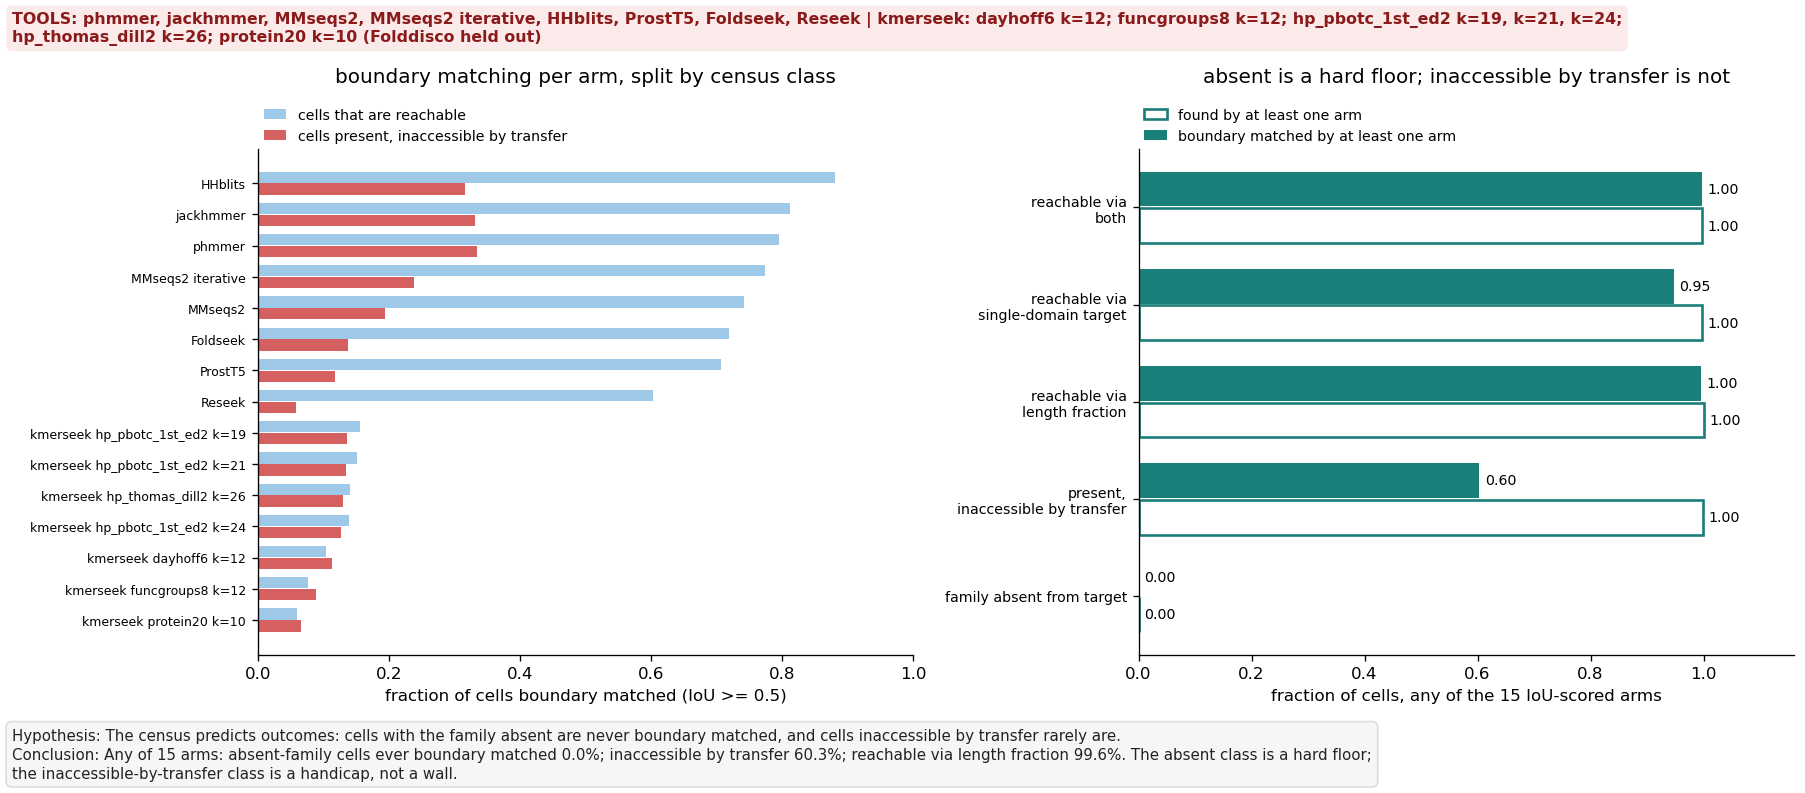

In [5]:
PAIRS = (
    TRUTH.rename({"accession": "query_acc"})
    .group_by("query_acc", "pfam_id")
    .agg(
        max_lf=pl.col("length_fraction").max(),
        mean_lf=pl.col("length_fraction").mean(),
        n_instances=pl.len(),
    )
    .join(AVAIL, on="pfam_id", how="left")
    .with_columns(
        present=pl.col("n_target_proteins") > 0,
        cond1=pl.col("max_lf") >= 0.5,
        cond2=pl.col("n_solo_targets") > 0,
    )
)
PAIRS = PAIRS.with_columns(
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2")),
    reach_class=pl.when(pl.col("n_target_proteins") == 0)
    .then(pl.lit("family absent from target"))
    .when((pl.col("max_lf") >= 0.5) & (pl.col("n_solo_targets") > 0))
    .then(pl.lit("reachable via both"))
    .when(pl.col("max_lf") >= 0.5)
    .then(pl.lit("reachable via length fraction"))
    .when(pl.col("n_solo_targets") > 0)
    .then(pl.lit("reachable via single-domain target"))
    .otherwise(pl.lit("present, inaccessible by transfer")),
)

BEST = (
    mu.focus_calls()
    .filter(pl.col("truth_set") == "pfam")
    .group_by("species", "tool", "variant", "query_acc", "pfam_id")
    .agg(
        best_iou=pl.col("iou").max(),
        best_cover=pl.col("cover").max(),
        any_tp=pl.col("is_tp").max(),
        n_calls=pl.len(),
    )
    .collect(engine="streaming")
)
ARMS = BEST.select("tool", "variant").unique()
GRID = (
    PAIRS.join(ARMS, how="cross")
    .join(BEST, on=["species", "tool", "variant", "query_acc", "pfam_id"], how="left")
    .with_columns(
        pl.col("best_iou").fill_null(0.0),
        pl.col("best_cover").fill_null(0.0),
        pl.col("any_tp").fill_null(False),
        pl.col("n_calls").fill_null(0),
        arm=pl.col("tool") + "." + pl.col("variant"),
    )
)
N_CELLS = PAIRS.height
print(
    f"protein-family pairs: {PAIRS['query_acc'].n_unique()} proteins, "
    f"{PAIRS.select('query_acc', 'pfam_id').n_unique()} pairs"
)
print(f"pair x species cells: {N_CELLS}, arms: {ARMS.height}, grid rows: {GRID.height}")

ALN = GRID.filter(pl.col("tool") != "folddisco")
per_arm = (
    ALN.group_by("arm")
    .agg(
        boundary_matched=(pl.col("best_iou") >= 0.5).mean().round(4),
        boundary_matched_if_reachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("reachable"))
        .mean()
        .round(4),
        boundary_matched_if_unreachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
        covered=(pl.col("best_cover") >= 0.5).mean().round(4),
    )
    .sort("boundary_matched", descending=True)
)
print()
print(f"Per arm, over all {N_CELLS:,} pair-species cells. Folddisco excluded (see 5.2).")
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=45):
    print(per_arm)

ever = ALN.group_by(
    "query_acc", "pfam_id", "species", "reach_class", "reachable", "present"
).agg(
    ever_boundary_matched=(pl.col("best_iou") >= 0.5).max(),
    ever_covered=(pl.col("best_cover") >= 0.5).max(),
)
by_class = ever.group_by("reach_class").agg(
    n=pl.len(),
    ever_boundary_matched=pl.col("ever_boundary_matched").mean().round(4),
    ever_covered=pl.col("ever_covered").mean().round(4),
)
by_class = pl.DataFrame({"reach_class": CLASS_ORDER}).join(
    by_class, on="reach_class", how="left"
)
print()
print("Union over the 15 IoU-scored arms: was the cell EVER boundary matched by anything?")
with pl.Config(tbl_rows=10, tbl_width_chars=150, fmt_str_lengths=45):
    print(by_class)
pred_reach = float(
    PAIRS.join(pl.DataFrame({"x": [0]}), how="cross")["reachable"].mean()
)
best_obs = float(per_arm["boundary_matched"].max())
print()
print(f"predicted reachable fraction (pair level): {pred_reach:.4f}")
print(f"best single arm actually boundary matched: {best_obs:.4f}")
print(
    "Condition 2 is a good sufficient rule and a poor necessary one: the absent class is"
)
print("boundary matched 0% of the time, but the 'inaccessible by transfer' class is not at 0%.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
ax = axes[0]
p = per_arm.sort("boundary_matched")
yy = np.arange(p.height)
ax.barh(
    yy + 0.19,
    p["boundary_matched_if_reachable"],
    0.36,
    color=mu.CENSUS_CLASS_COLORS["reachable via single-domain target"],
    label="cells that are reachable",
)
ax.barh(
    yy - 0.19,
    p["boundary_matched_if_unreachable"],
    0.36,
    color=mu.CENSUS_CLASS_COLORS["present, inaccessible by transfer"],
    label="cells present, inaccessible by transfer",
)
ax.set_yticks(yy)
ax.set_yticklabels([mu.arm_pretty(a) for a in p["arm"]], fontsize=7.5)
ax.set_xlim(0, 1)
ax.set_xlabel("fraction of cells boundary matched (IoU >= 0.5)")
ax.set_title("boundary matching per arm, split by census class")
mu.legend_above(ax, ncol=1)

ax = axes[1]
cc = [c for c in CLASS_ORDER]
dv = [by_class.filter(pl.col("reach_class") == c)["ever_boundary_matched"][0] for c in cc]
cv = [by_class.filter(pl.col("reach_class") == c)["ever_covered"][0] for c in cc]
yy = np.arange(len(cc))
ax.barh(yy - 0.19, cv, 0.36, label="found by at least one arm", **mu.outcome_style("found"))
ax.barh(yy + 0.19, dv, 0.36, label="boundary matched by at least one arm", **mu.outcome_style("boundary matched"))
for i, (a_, b_) in enumerate(zip(cv, dv)):
    ax.text(a_ + 0.01, i - 0.19, f"{a_:.2f}", va="center", fontsize=8.5)
    ax.text(b_ + 0.01, i + 0.19, f"{b_:.2f}", va="center", fontsize=8.5)
ax.set_yticks(yy)
ax.set_yticklabels(
    [c.replace(", ", ",\n").replace(" via ", " via\n") for c in cc], fontsize=8.5
)
ax.set_xlim(0, 1.16)
ax.set_xlabel("fraction of cells, any of the 15 IoU-scored arms")
ax.set_title("absent is a hard floor; inaccessible by transfer is not")
mu.legend_above(ax, ncol=1)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
bc = {r["reach_class"]: r for r in by_class.iter_rows(named=True)}
mu.finish_figure(
    fig,
    FIG_DIR / "226_predicts_recall.png",
    tools=mu.tools_text(mu.IOU_SCORED_TOOLS, kmerseek=mu.kmerseek_labels([a.split(".")[1] for a in sorted(ALN["arm"].unique().to_list()) if a.startswith("kmerseek")]), note="Folddisco held out"),
    hypothesis="The census predicts outcomes: cells with the family absent are never boundary matched, and cells inaccessible by transfer rarely are.",
    conclusion=(
        f"Any of 15 arms: absent-family cells ever boundary matched {bc[CLASS_ORDER[0]]['ever_boundary_matched']:.1%}; "
        f"inaccessible by transfer {bc[CLASS_ORDER[1]]['ever_boundary_matched']:.1%}; reachable via length fraction "
        f"{bc[CLASS_ORDER[2]]['ever_boundary_matched']:.1%}. The absent class is a hard floor; the inaccessible-by-transfer class is a handicap, not a wall."
    ),
)


### 4.3 How much do the two covariates explain?

Per (family, species) recall regressed on length fraction and single-domain-target count, on
the families present in that target, for eight comparison tools and kmerseek hp_pbotc_1st_ed2
k=19. `max_target_length_fraction` is added as a third
covariate: it is the same mechanism as condition 2 stated continuously, and it is a stronger
predictor than the binary partner-free test.

Variance in per-(family, species) recall explained, families present in the target:
shape: (9, 8)
┌──────────────────────────────────────┬─────────┬────────────────────┬───────────────┬──────────────────┬───────────────────┬───────────────────┬─────────────┐
│ arm                                  ┆ n_cells ┆ r2_length_fraction ┆ r2_log_n_solo ┆ r2_max_target_lf ┆ r2_two_conditions ┆ r2_plus_target_lf ┆ r2_all_four │
│ ---                                  ┆ ---     ┆ ---                ┆ ---           ┆ ---              ┆ ---               ┆ ---               ┆ ---         │
│ str                                  ┆ i64     ┆ f64                ┆ f64           ┆ f64              ┆ f64               ┆ f64               ┆ f64         │
╞══════════════════════════════════════╪═════════╪════════════════════╪═══════════════╪══════════════════╪═══════════════════╪═══════════════════╪═════════════╡
│ hmmer3_phmmer.default                ┆ 6209    ┆ 0.133              ┆ 0.186         ┆ 0.225    

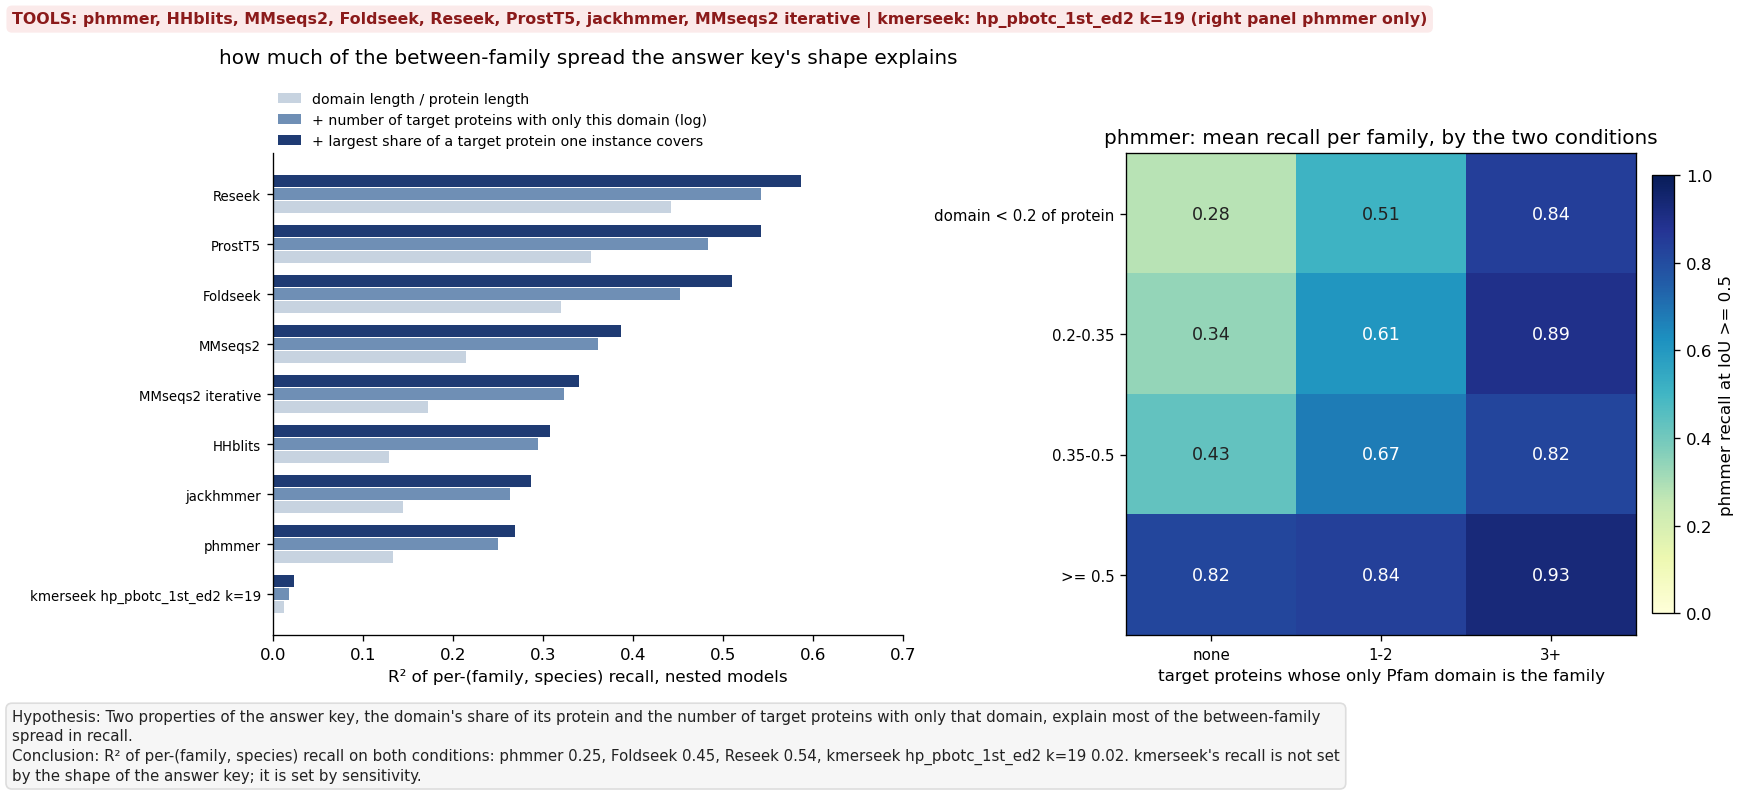

In [6]:
fam_rec_rows = []
FIT_ARMS = [
    "hmmer3_phmmer.default",
    "hhblits.single_seq",
    "mmseqs2_seqseq.s7",
    "foldseek.3di_aa",
    "reseek.verysensitive",
    "prostt5.3di_from_seq",
    "hmmer3_jackhmmer.n3",
    "mmseqs2_iterative.s7",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
]
fam_tab = (
    ALN.filter(pl.col("present"))
    .group_by("arm", "pfam_id", "species")
    .agg(
        recall=(pl.col("best_iou") >= 0.5).mean(),
        mean_lf=pl.col("mean_lf").mean(),
        n_solo=pl.col("n_solo_targets").max(),
        n_target=pl.col("n_target_proteins").max(),
        max_tlf=pl.col("max_target_length_fraction").max(),
        n=pl.len(),
    )
)


def r2(y, X):
    X = np.column_stack([np.ones(len(y))] + X)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1.0 - float(resid @ resid) / float(((y - y.mean()) ** 2).sum())


for arm in FIT_ARMS:
    s = fam_tab.filter(pl.col("arm") == arm)
    y = s["recall"].to_numpy()
    lf = s["mean_lf"].to_numpy()
    solo = np.log1p(s["n_solo"].to_numpy().astype(float))
    ntg = np.log1p(s["n_target"].to_numpy().astype(float))
    tlf = s["max_tlf"].to_numpy()
    fam_rec_rows.append(
        {
            "arm": arm,
            "n_cells": s.height,
            "r2_length_fraction": round(r2(y, [lf]), 3),
            "r2_log_n_solo": round(r2(y, [solo]), 3),
            "r2_max_target_lf": round(r2(y, [tlf]), 3),
            "r2_two_conditions": round(r2(y, [lf, solo]), 3),
            "r2_plus_target_lf": round(r2(y, [lf, solo, tlf]), 3),
            "r2_all_four": round(r2(y, [lf, solo, tlf, ntg]), 3),
        }
    )
fit = pl.DataFrame(fam_rec_rows)
print(
    "Variance in per-(family, species) recall explained, families present in the target:"
)
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(fit)
print()
print(
    "Recall by length-fraction band and single-domain-target availability, phmmer pooled:"
)
ph = fam_tab.filter(pl.col("arm") == "hmmer3_phmmer.default")
grid_tab = (
    ph.with_columns(
        lf_band=pl.when(pl.col("mean_lf") < 0.2)
        .then(pl.lit("lf < 0.2"))
        .when(pl.col("mean_lf") < 0.35)
        .then(pl.lit("0.2-0.35"))
        .when(pl.col("mean_lf") < 0.5)
        .then(pl.lit("0.35-0.5"))
        .otherwise(pl.lit("lf >= 0.5")),
        solo_band=pl.when(pl.col("n_solo") == 0)
        .then(pl.lit("no solo target"))
        .when(pl.col("n_solo") <= 2)
        .then(pl.lit("1-2 solo"))
        .otherwise(pl.lit("3+ solo")),
    )
    .group_by("lf_band", "solo_band")
    .agg(recall=pl.col("recall").mean().round(3), n=pl.len())
)
LFB = ["lf < 0.2", "0.2-0.35", "0.35-0.5", "lf >= 0.5"]
SB = ["no solo target", "1-2 solo", "3+ solo"]
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(
        grid_tab.pivot(on="solo_band", index="lf_band", values="recall").select(
            ["lf_band"]
            + [c for c in SB if c in grid_tab["solo_band"].unique().to_list()]
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
f = fit.sort("r2_two_conditions")
yy = np.arange(f.height)
ramp = ["#C7D3E0", "#6F8FB5", "#1F3B73"]
ax.barh(yy - 0.26, f["r2_length_fraction"], 0.24, color=ramp[0], label="domain length / protein length")
ax.barh(yy, f["r2_two_conditions"], 0.24, color=ramp[1], label="+ number of target proteins with only this domain (log)")
ax.barh(yy + 0.26, f["r2_plus_target_lf"], 0.24, color=ramp[2], label="+ largest share of a target protein one instance covers")
ax.set_yticks(yy)
ax.set_yticklabels([mu.arm_pretty(a) for a in f["arm"]], fontsize=8)
ax.set_xlim(0, 0.7)
ax.set_xlabel("R² of per-(family, species) recall, nested models")
ax.set_title("how much of the between-family spread the answer key's shape explains")
mu.legend_above(ax, ncol=1)

ax = axes[1]
LFB_LABELS = ["domain < 0.2 of protein", "0.2-0.35", "0.35-0.5", ">= 0.5"]
SB_LABELS = ["none", "1-2", "3+"]
mat = np.full((len(LFB), len(SB)), np.nan)
for i, lb in enumerate(LFB):
    for j, sb in enumerate(SB):
        r = grid_tab.filter((pl.col("lf_band") == lb) & (pl.col("solo_band") == sb))
        if r.height:
            mat[i, j] = r["recall"][0]
im = ax.imshow(mat, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(SB)))
ax.set_xticklabels(SB_LABELS, fontsize=9)
ax.set_xlabel("target proteins whose only Pfam domain is the family")
ax.set_yticks(range(len(LFB)))
ax.set_yticklabels(LFB_LABELS, fontsize=9)
for i in range(len(LFB)):
    for j in range(len(SB)):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=10.5,
                    color="white" if mat[i, j] > 0.6 else "#222222")
ax.set_title("phmmer: mean recall per family, by the two conditions")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="phmmer recall at IoU >= 0.5")
for s_ in ("right", "top"):
    axes[0].spines[s_].set_visible(False)
fr = {r["arm"]: r for r in fit.iter_rows(named=True)}
mu.finish_figure(
    fig,
    FIG_DIR / "226_covariates.png",
    tools=mu.tools_text([a.split(".")[0] for a in FIT_ARMS if not a.startswith("kmerseek")], kmerseek=[mu.BEST_KMERSEEK], note="right panel phmmer only"),
    hypothesis="Two properties of the answer key, the domain's share of its protein and the number of target proteins with only that domain, explain most of the between-family spread in recall.",
    conclusion=(
        f"R² of per-(family, species) recall on both conditions: phmmer {fr['hmmer3_phmmer.default']['r2_two_conditions']:.2f}, "
        f"Foldseek {fr['foldseek.3di_aa']['r2_two_conditions']:.2f}, Reseek {fr['reseek.verysensitive']['r2_two_conditions']:.2f}, "
        f"kmerseek hp_pbotc_1st_ed2 k=19 {fr['kmerseek.hp_pbotc_1st_ed2_k19_lcTrue']['r2_two_conditions']:.2f}. "
        "kmerseek's recall is not set by the shape of the answer key; it is set by sensitivity."
    ),
)


## 5. Three things this explains

### 5.1 Why every Fmax is low

Fmax in this run divides by `n_truth_instances`, which is the full 2,435 for every species.
The census says a large block of that denominator cannot be scored. Recomputing recall
against the reachable block instead shows how much of the low absolute number is the
denominator rather than the search.

Pipeline Fmax, pfam truth, best variant per (tool, species):
shape: (10, 4)
┌───────────────────┬───────────┬──────────┬──────────┐
│ tool              ┆ mean_fmax ┆ min_fmax ┆ max_fmax │
│ ---               ┆ ---       ┆ ---      ┆ ---      │
│ str               ┆ f64       ┆ f64      ┆ f64      │
╞═══════════════════╪═══════════╪══════════╪══════════╡
│ hmmer3_phmmer     ┆ 0.287     ┆ 0.119    ┆ 0.336    │
│ mmseqs2_seqseq    ┆ 0.282     ┆ 0.111    ┆ 0.332    │
│ mmseqs2_iterative ┆ 0.28      ┆ 0.104    ┆ 0.33     │
│ hhblits           ┆ 0.28      ┆ 0.123    ┆ 0.327    │
│ hmmer3_jackhmmer  ┆ 0.263     ┆ 0.12     ┆ 0.303    │
│ foldseek          ┆ 0.221     ┆ 0.119    ┆ 0.254    │
│ prostt5           ┆ 0.194     ┆ 0.111    ┆ 0.242    │
│ reseek            ┆ 0.159     ┆ 0.033    ┆ 0.279    │
│ folddisco         ┆ 0.132     ┆ 0.02     ┆ 0.446    │
│ kmerseek          ┆ 0.114     ┆ 0.0      ┆ 0.427    │
└───────────────────┴───────────┴──────────┴──────────┘

Own recall, averaged over t

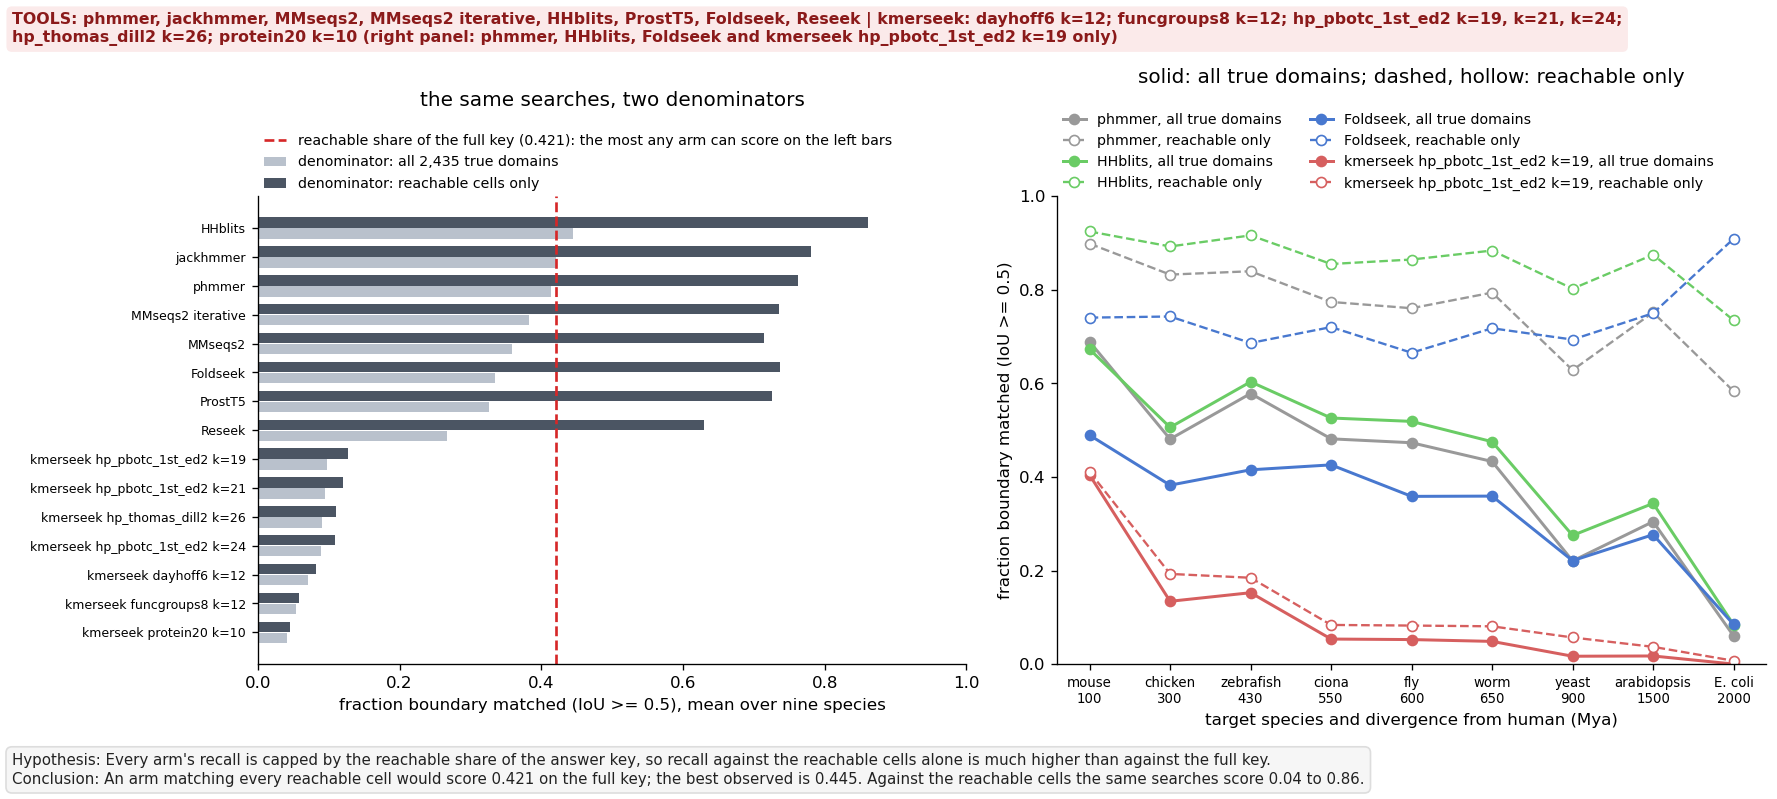

In [7]:
sp_arm = ALN.group_by("arm", "species").agg(
    recall_all=(pl.col("best_iou") >= 0.5).mean(),
    recall_reach=(pl.col("best_iou") >= 0.5).filter(pl.col("reachable")).mean(),
    n_reach=pl.col("reachable").sum(),
)
tool_fmax = (
    metrics.sort("fmax", descending=True)
    .group_by("tool", "species")
    .head(1)
    .select(
        "tool",
        "variant",
        "species",
        "fmax",
        "fmax_recall",
        "fmax_precision",
        "interval_semantics",
    )
)
print("Pipeline Fmax, pfam truth, best variant per (tool, species):")
with pl.Config(tbl_rows=15, tbl_width_chars=170):
    print(
        tool_fmax.group_by("tool")
        .agg(
            mean_fmax=pl.col("fmax").mean().round(3),
            min_fmax=pl.col("fmax").min().round(3),
            max_fmax=pl.col("fmax").max().round(3),
        )
        .sort("mean_fmax", descending=True)
    )
print()
summ = (
    sp_arm.group_by("arm")
    .agg(
        recall_all=pl.col("recall_all").mean().round(4),
        recall_reach=pl.col("recall_reach").mean().round(4),
    )
    .sort("recall_all", descending=True)
)
print(
    "Own recall, averaged over the nine species: full answer key vs reachable block only:"
)
with pl.Config(tbl_rows=20, tbl_width_chars=170, fmt_str_lengths=45):
    print(summ)
print()
print(
    f"An arm that matched the boundary of every reachable cell and nothing else would score recall "
    f"{pred_reach:.3f}"
)
print(
    f"on the full key. The best observed is {best_obs:.3f}. The 0.12-0.29 mean-Fmax band"
)
print(
    "above is what a recall ceiling near 0.42 looks like once precision is folded in."
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
ax = axes[0]
s = summ.sort("recall_all")
yy = np.arange(s.height)
ax.barh(yy - 0.19, s["recall_all"], 0.36, color="#B9C1CC", label=f"denominator: all {N_TRUTH:,} true domains")
ax.barh(yy + 0.19, s["recall_reach"], 0.36, color="#4B5563", label="denominator: reachable cells only")
ax.axvline(pred_reach, color="#D62728", lw=1.6, ls="--",
           label=f"reachable share of the full key ({pred_reach:.3f}): the most any arm can score on the left bars")
ax.set_yticks(yy)
ax.set_yticklabels([mu.arm_pretty(a) for a in s["arm"]], fontsize=7.5)
ax.set_xlim(0, 1)
ax.set_xlabel("fraction boundary matched (IoU >= 0.5), mean over nine species")
ax.set_title("the same searches, two denominators")
mu.legend_above(ax, ncol=1)

ax = axes[1]
for arm in ["hmmer3_phmmer.default", "hhblits.single_seq", "foldseek.3di_aa", "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"]:
    colour = mu.TOOL_FAMILY_COLORS[mu.TOOL_FAMILY[arm.split(".")[0]]]
    s2 = sp_arm.filter(pl.col("arm") == arm).join(order, on="species").sort("_o")
    ax.plot(range(len(mu.SPECIES_ORDER)), s2["recall_all"], "o-", color=colour, lw=1.8,
            label=f"{mu.arm_pretty(arm)}, all true domains")
    ax.plot(range(len(mu.SPECIES_ORDER)), s2["recall_reach"], "o--", color=colour, lw=1.4,
            markerfacecolor="white", label=f"{mu.arm_pretty(arm)}, reachable only")
ax.set_xticks(range(len(mu.SPECIES_ORDER)))
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_xlabel("target species and divergence from human (Mya)")
ax.set_ylim(0, 1)
ax.set_ylabel("fraction boundary matched (IoU >= 0.5)")
ax.set_title("solid: all true domains; dashed, hollow: reachable only")
mu.legend_above(ax, ncol=2)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "226_fmax_vs_census.png",
    tools=mu.tools_text(mu.IOU_SCORED_TOOLS, kmerseek=mu.kmerseek_labels([a.split(".")[1] for a in sorted(ALN["arm"].unique().to_list()) if a.startswith("kmerseek")]), note="right panel: phmmer, HHblits, Foldseek and kmerseek hp_pbotc_1st_ed2 k=19 only"),
    hypothesis="Every arm's recall is capped by the reachable share of the answer key, so recall against the reachable cells alone is much higher than against the full key.",
    conclusion=(
        f"An arm matching every reachable cell would score {pred_reach:.3f} on the full key; the best observed is {best_obs:.3f}. "
        f"Against the reachable cells the same searches score {summ['recall_reach'].min():.2f} to {summ['recall_reach'].max():.2f}."
    ),
)


### 5.2 Why folddisco looks different

folddisco is scored with `interval_semantics = "motif"` instead of `"alignment"`, so its
true positives are decided by coverage rather than by IoU. That exempts it from exactly the
block the census says is unscorable, which is the whole of its advantage.

interval semantics per tool, pfam truth:
shape: (10, 3)
┌───────────────────┬────────────────────┬─────────────────┐
│ tool              ┆ interval_semantics ┆ point_semantics │
│ ---               ┆ ---                ┆ ---             │
│ str               ┆ list[str]          ┆ list[str]       │
╞═══════════════════╪════════════════════╪═════════════════╡
│ folddisco         ┆ ["motif"]          ┆ ["cover"]       │
│ foldseek          ┆ ["alignment"]      ┆ ["cover"]       │
│ hhblits           ┆ ["alignment"]      ┆ ["cover"]       │
│ hmmer3_jackhmmer  ┆ ["alignment"]      ┆ ["cover"]       │
│ hmmer3_phmmer     ┆ ["alignment"]      ┆ ["cover"]       │
│ kmerseek          ┆ ["alignment"]      ┆ ["cover"]       │
│ mmseqs2_iterative ┆ ["alignment"]      ┆ ["cover"]       │
│ mmseqs2_seqseq    ┆ ["alignment"]      ┆ ["cover"]       │
│ prostt5           ┆ ["alignment"]      ┆ ["cover"]       │
│ reseek            ┆ ["alignment"]      ┆ ["cover"]       │
└───────────────────┴────────

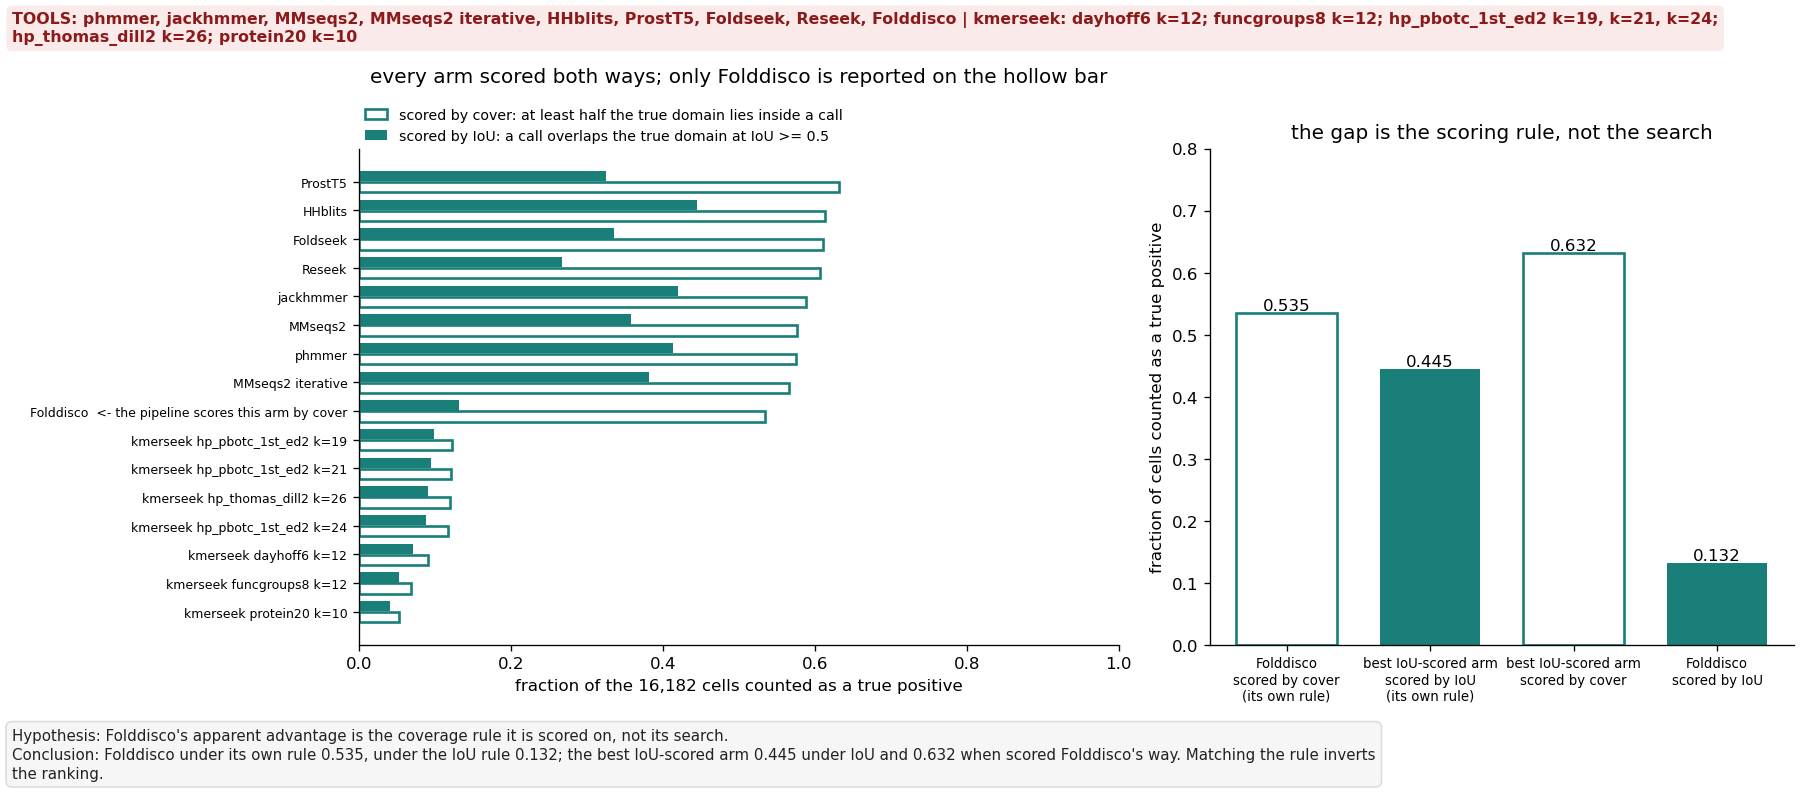

In [8]:
sem = (
    metrics.group_by("tool")
    .agg(
        interval_semantics=pl.col("interval_semantics").unique(),
        point_semantics=pl.col("point_semantics").unique(),
    )
    .sort("tool")
)
print("interval semantics per tool, pfam truth:")
with pl.Config(tbl_rows=15, tbl_width_chars=150):
    print(sem)

fd_cmp = (
    GRID.group_by("arm")
    .agg(
        iou50=(pl.col("best_iou") >= 0.5).mean().round(4),
        cover50=(pl.col("best_cover") >= 0.5).mean().round(4),
        pipeline_tp=pl.col("any_tp").mean().round(4),
        iou50_unreachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
        cover50_unreachable=(pl.col("best_cover") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
    )
    .sort("cover50", descending=True)
)
print()
print(
    "Scored two ways. `pipeline_tp` is the run's own flag, which is IoU for every arm"
)
print("except folddisco, where it is cover:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(fd_cmp)

fd = fd_cmp.filter(pl.col("arm") == "folddisco.motif")
aln_best_tp = fd_cmp.filter(pl.col("arm") != "folddisco.motif")["pipeline_tp"].max()
aln_best_cov = fd_cmp.filter(pl.col("arm") != "folddisco.motif")["cover50"].max()
print()
print(f"folddisco under its own rule:                       {fd['pipeline_tp'][0]:.4f}")
print(f"best alignment arm under the IoU rule:              {aln_best_tp:.4f}")
print(f"best alignment arm scored the way folddisco is:     {aln_best_cov:.4f}")
print(f"folddisco under the IoU rule the others face:       {fd['iou50'][0]:.4f}")
print()
mouse_fmax = (
    tool_fmax.filter(pl.col("species") == "mouse")
    .select("tool", "interval_semantics", pl.col("fmax").round(3))
    .sort("fmax", descending=True)
)
print("Mouse Fmax, best variant per tool:")
with pl.Config(tbl_rows=15, tbl_width_chars=140):
    print(mouse_fmax)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
f = fd_cmp.sort("cover50")
yy = np.arange(f.height)
ax.barh(yy - 0.19, f["cover50"], 0.36, label="scored by cover: " + mu.FOUND_LABEL.split(": ")[1], **mu.outcome_style("found"))
ax.barh(yy + 0.19, f["iou50"], 0.36, label="scored by IoU: " + mu.BOUNDARY_LABEL.split(": ")[1], **mu.outcome_style("boundary matched"))
ax.set_yticks(yy)
labels = [mu.arm_pretty(a) + ("  <- the pipeline scores this arm by cover" if a == "folddisco.motif" else "") for a in f["arm"]]
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlim(0, 1)
ax.set_xlabel(f"fraction of the {N_CELLS:,} cells counted as a true positive")
ax.set_title("every arm scored both ways; only Folddisco is reported on the hollow bar")
mu.legend_above(ax, ncol=1)

ax = axes[1]
labels = [
    "Folddisco\nscored by cover\n(its own rule)",
    "best IoU-scored arm\nscored by IoU\n(its own rule)",
    "best IoU-scored arm\nscored by cover",
    "Folddisco\nscored by IoU",
]
vals = [fd["pipeline_tp"][0], aln_best_tp, aln_best_cov, fd["iou50"][0]]
kinds = ["found", "boundary matched", "found", "boundary matched"]
for i, (v, k) in enumerate(zip(vals, kinds)):
    ax.bar([i], [v], width=0.7, **mu.outcome_style(k))
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 0.8)
ax.set_ylabel("fraction of cells counted as a true positive")
ax.set_title("the gap is the scoring rule, not the search")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "226_folddisco_gap.png",
    tools=mu.tools_text(mu.COMPARISON_TOOLS, kmerseek=mu.kmerseek_labels([a.split(".")[1] for a in sorted(GRID["arm"].unique().to_list()) if a.startswith("kmerseek")])),
    hypothesis="Folddisco's apparent advantage is the coverage rule it is scored on, not its search.",
    conclusion=(
        f"Folddisco under its own rule {fd['pipeline_tp'][0]:.3f}, under the IoU rule {fd['iou50'][0]:.3f}; the best IoU-scored arm "
        f"{aln_best_tp:.3f} under IoU and {aln_best_cov:.3f} when scored Folddisco's way. Matching the rule inverts the ranking."
    ),
)


### 5.3 kmerseek: high IoU on true positives, low recall

The claim to test, for kmerseek hp_pbotc_1st_ed2 k=19 and the other six kmerseek arms against
the eight IoU-scored comparison tools, is that kmerseek's true positives sit high on IoU because they are
selected from the easy end of the census (short domains in mostly-domain proteins, families
with many partner-free targets). If that were the reason, kmerseek's true positives would be
enriched for high length fraction relative to other arms.

mean length fraction of the reachable pool, for reference: 0.376

True-positive profile per arm. If kmerseek's TPs were an easy-end selection,
`mean_lf_of_tp` and `frac_tp_cond1` would be highest for kmerseek:
shape: (15, 9)
┌──────────────────────────────────────┬──────┬───────────────┬───────────────┬───┬───────────────────┬─────────┬──────────────────┬────────────────────────────────┐
│ arm                                  ┆ n_tp ┆ median_iou_tp ┆ mean_lf_of_tp ┆ … ┆ median_solo_of_tp ┆ covered ┆ boundary_matched ┆ boundary_matched_given_covered │
│ ---                                  ┆ ---  ┆ ---           ┆ ---           ┆   ┆ ---               ┆ ---     ┆ ---              ┆ ---                            │
│ str                                  ┆ i64  ┆ f64           ┆ f64           ┆   ┆ f64               ┆ f64     ┆ f64              ┆ f64                            │
╞══════════════════════════════════════╪══════╪═══════════════╪═══════════════╪═══╪═══════════════════╪════════

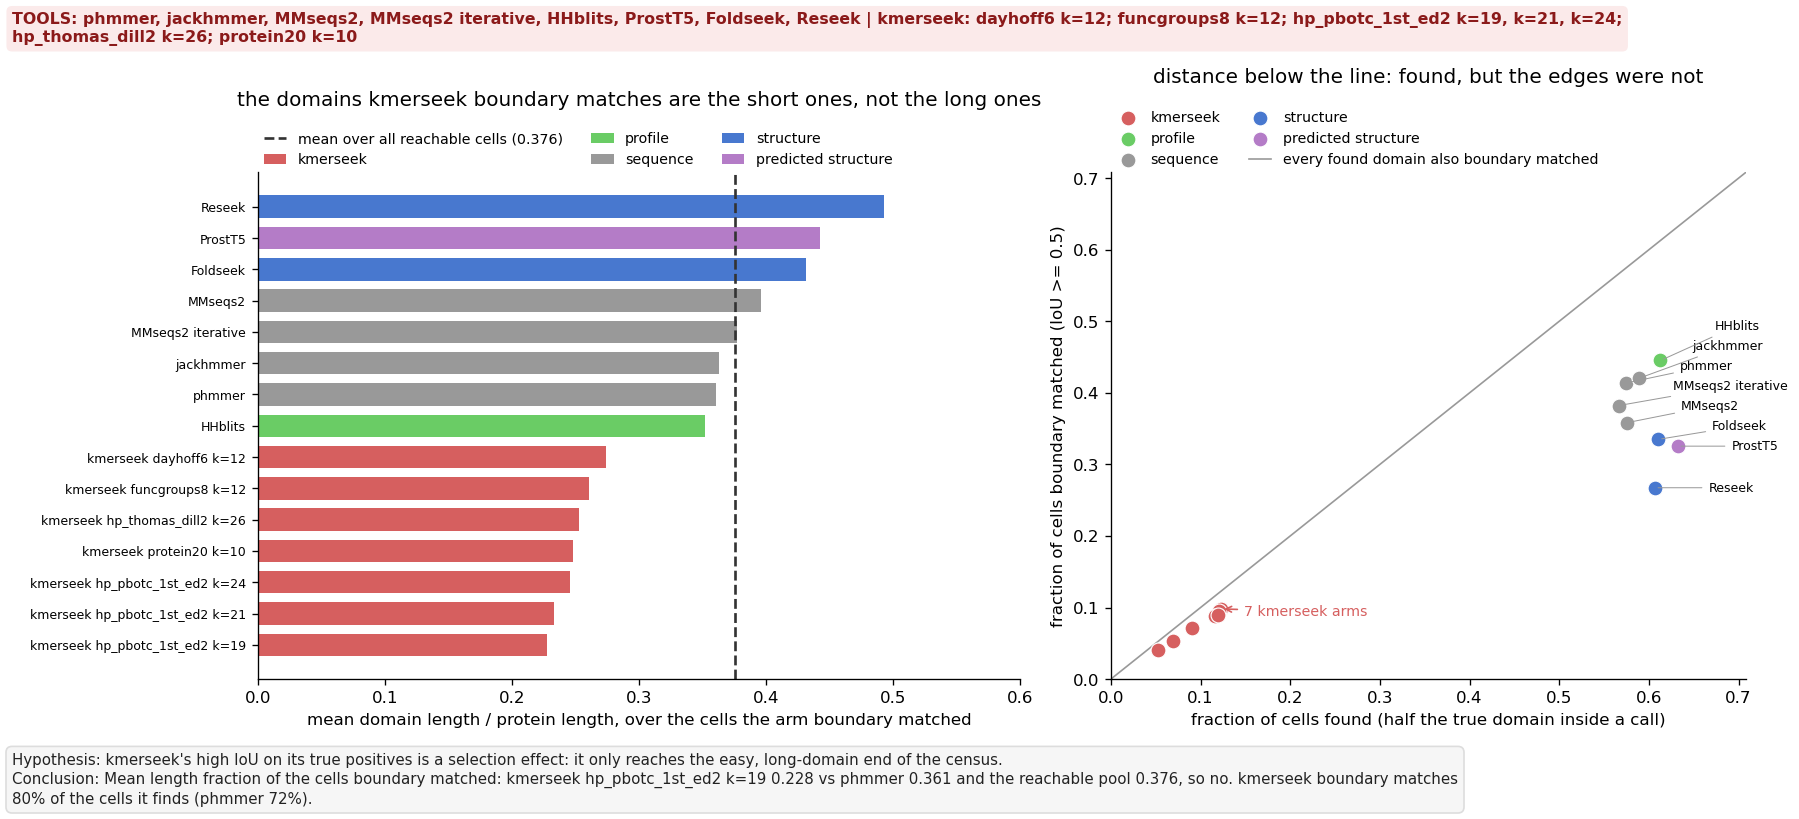

In [9]:
KM = "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"
tp_profile = []
for arm in sorted(ALN["arm"].unique().to_list()):
    s = ALN.filter(pl.col("arm") == arm)
    tp = s.filter(pl.col("best_iou") >= 0.5)
    cov = s.filter(pl.col("best_cover") >= 0.5)
    tp_profile.append(
        {
            "arm": arm,
            "n_tp": tp.height,
            "median_iou_tp": (
                None if tp.height == 0 else round(tp["best_iou"].median(), 3)
            ),
            "mean_lf_of_tp": None if tp.height == 0 else round(tp["max_lf"].mean(), 3),
            "frac_tp_cond1": (
                None
                if tp.height == 0
                else round(float((tp["max_lf"] >= 0.5).mean()), 3)
            ),
            "median_solo_of_tp": (
                None if tp.height == 0 else float(tp["n_solo_targets"].median())
            ),
            "covered": round(cov.height / s.height, 4),
            "boundary_matched": round(tp.height / s.height, 4),
            "boundary_matched_given_covered": (
                None if cov.height == 0 else round(tp.height / cov.height, 3)
            ),
        }
    )
prof = pl.DataFrame(tp_profile).sort("boundary_matched_given_covered", descending=True)
pool_lf = round(float(ALN.filter(pl.col("reachable"))["max_lf"].mean()), 3)
print(f"mean length fraction of the reachable pool, for reference: {pool_lf}")
print()
print("True-positive profile per arm. If kmerseek's TPs were an easy-end selection,")
print("`mean_lf_of_tp` and `frac_tp_cond1` would be highest for kmerseek:")
with pl.Config(tbl_rows=20, tbl_width_chars=210, fmt_str_lengths=45):
    print(prof)

km_med = metrics.filter(pl.col("tool") == "kmerseek")["median_iou_tp"].median()
ph_med = metrics.filter(pl.col("tool") == "hmmer3_phmmer")["median_iou_tp"].median()
mm_med = metrics.filter(pl.col("tool") == "mmseqs2_seqseq")["median_iou_tp"].median()
print()
print("Pipeline `median_iou_tp` (median over TP calls, not per instance), pfam truth:")
print(f"  kmerseek {km_med:.3f}   phmmer {ph_med:.3f}   MMseqs2 {mm_med:.3f}")
print("kmerseek is not the highest on that column in the pfam truth set.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.2, 1]})
fam_of = lambda a: mu.TOOL_FAMILY[a.split(".")[0]]
ax = axes[0]
p = prof.sort("mean_lf_of_tp")
yy = np.arange(p.height)
seen = set()
for i, a in enumerate(p["arm"]):
    fam = fam_of(a)
    ax.barh(i, p["mean_lf_of_tp"][i], 0.72, color=mu.TOOL_FAMILY_COLORS[fam],
            label=None if fam in seen else fam)
    seen.add(fam)
ax.axvline(pool_lf, color="#333333", lw=1.6, ls="--", label=f"mean over all reachable cells ({pool_lf:.3f})")
ax.set_yticks(yy)
ax.set_yticklabels([mu.arm_pretty(a) for a in p["arm"]], fontsize=7.5)
ax.set_xlim(0, 0.6)
ax.set_xlabel("mean domain length / protein length, over the cells the arm boundary matched")
ax.set_title("the domains kmerseek boundary matches are the short ones, not the long ones")
mu.legend_above(ax, ncol=3)

ax = axes[1]
seen = set()
for row in prof.iter_rows(named=True):
    fam = fam_of(row["arm"])
    ax.scatter(row["covered"], row["boundary_matched"], s=80, color=mu.TOOL_FAMILY_COLORS[fam],
               edgecolor="white", linewidth=0.7, zorder=3, label=None if fam in seen else fam)
    seen.add(fam)
lim = float(max(prof["covered"].max(), prof["boundary_matched"].max())) * 1.12
ax.plot([0, lim], [0, lim], color="#999999", lw=1.0, label="every found domain also boundary matched")
# Stagger the baseline labels so none overlap: sort by y and enforce a minimum gap.
base = prof.filter(~pl.col("arm").str.starts_with("kmerseek")).sort("boundary_matched")
ys = base["boundary_matched"].to_list()
placed = []
for yv in ys:
    yv = max(yv, (placed[-1] + 0.028) if placed else yv)
    placed.append(yv)
for row, ytext in zip(base.iter_rows(named=True), placed):
    ax.annotate(mu.arm_pretty(row["arm"]), (row["covered"], row["boundary_matched"]),
                xytext=(row["covered"] + 0.06, ytext), textcoords="data", fontsize=7.5, va="center",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="#999999"))
km = prof.filter(pl.col("arm").str.starts_with("kmerseek"))
ax.annotate(f"{km.height} kmerseek arms", (km["covered"].max(), km["boundary_matched"].max()),
            fontsize=8.5, color=mu.TOOL_FAMILY_COLORS["kmerseek"], xytext=(14, -4), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1.0, color=mu.TOOL_FAMILY_COLORS["kmerseek"]))
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("fraction of cells found (half the true domain inside a call)")
ax.set_ylabel("fraction of cells boundary matched (IoU >= 0.5)")
ax.set_title("distance below the line: found, but the edges were not")
mu.legend_above(ax, ncol=2)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
pr = {r["arm"]: r for r in prof.iter_rows(named=True)}
mu.finish_figure(
    fig,
    FIG_DIR / "226_kmerseek_iou.png",
    tools=mu.tools_text(mu.IOU_SCORED_TOOLS, kmerseek=mu.kmerseek_labels([a.split(".")[1] for a in sorted(ALN["arm"].unique().to_list()) if a.startswith("kmerseek")])),
    hypothesis="kmerseek's high IoU on its true positives is a selection effect: it only reaches the easy, long-domain end of the census.",
    conclusion=(
        f"Mean length fraction of the cells boundary matched: kmerseek hp_pbotc_1st_ed2 k=19 {pr[KM]['mean_lf_of_tp']:.3f} vs phmmer "
        f"{pr['hmmer3_phmmer.default']['mean_lf_of_tp']:.3f} and the reachable pool {pool_lf:.3f}, so no. kmerseek boundary matches "
        f"{pr[KM]['boundary_matched_given_covered']:.0%} of the cells it finds (phmmer {pr['hmmer3_phmmer.default']['boundary_matched_given_covered']:.0%})."
    ),
)


## Summary

Of the 21,915 (domain instance, target species) pairs in the answer key, 32.1% have the Pfam
family absent from the target proteome and 21.7% have it present but failing both of the
conditions that make a true positive geometrically possible. 53.9% is therefore not predicted
reachable and 46.1% is. Per species the reachable fraction runs from 0.660 in mouse down to
0.064 in E. coli, with chicken 0.469 and zebrafish 0.605. The expectation about domain sizes
holds: the median truth domain is 89 aa in a 598-aa protein, median length fraction 0.142,
and only 406 of 2,435 instances (16.7%) are at least half their protein.

On the 52 MHC domains the classification splits outcomes cleanly: the ten headline arms
boundary match 75.3% of predicted-reachable (gene, family, species) cells and 6.5% of the
rest, and 98.4% of reachable cells are boundary matched by at least one arm against 20.8% of
the rest.

The absent class is a hard floor and the inaccessible-by-transfer class is not. No cell whose family is
missing from the target was boundary matched by any of the fifteen IoU-scored arms, in any
species, ever. The length-fraction class is boundary matched by at least one arm 99.6% of the
time and the single-domain-target class 94.7%, so both conditions work as sufficient rules.
But the inaccessible-by-transfer class is still boundary matched by at least one arm 60.3% of the
time, so neither condition is necessary: a local alignment against a multi-domain target can
stop at the domain and inherit a tight boundary anyway. For a single arm the effect is a
large handicap rather than an impossibility: phmmer boundary matches 79.5% of
predicted-reachable cells against 33.4% of the inaccessible-by-transfer cells, and HHblits 88.0% against 31.6%. 99.8% of the inaccessible-by-transfer cells are found by
some arm, so what is lost there is the boundary, not the detection.

The two covariates explain a third to a half of the between-family spread. On per-(family,
species) recall, length fraction alone gives R² 0.13-0.44 across the eight IoU-scored
comparison tools, adding log single-domain-target count reaches 0.25-0.54, and adding the
largest fraction of a target protein that one instance of the family occupies reaches
0.27-0.59. That last covariate is condition 2 stated continuously and is the stronger of the
two target-side terms. The structure-based tools (Reseek 0.54, ProstT5 0.48, Foldseek 0.45)
are the most predictable from truth-set geometry alone; the HMMER-family tools the least
(0.25-0.30). kmerseek hp_pbotc_1st_ed2 k=19 is the exception at R² 0.02, because its recall
is limited by sensitivity rather than by boundary geometry.

Every reported Fmax sits on a denominator roughly half of which cannot be answered. An arm
that boundary matched every predicted-reachable cell and nothing else would score recall
0.421 on the full key; the best observed single arm is 0.445, slightly above, because
condition 2 is not necessary. Mean Fmax across the nine species is 0.114-0.287 depending on
tool, which is what a recall ceiling near 0.42 looks like once precision is folded in.
Against the reachable block alone the same searches score 0.63-0.86.

Folddisco is the only arm with `interval_semantics = "motif"` and `point_semantics =
"cover"`, so its true positives are decided by coverage rather than IoU. Under its own rule
it counts 53.5% of cells as true positives; under the IoU rule the other arms face, 13.2%.
Its median IoU on its own true positives is 0.16, and it clears IoU 0.5 on 0.4% of the
inaccessible-by-transfer cells against 79% found. Scoring the best IoU-scored tool the way Folddisco is
scored gives 63.2%, above Folddisco, so the ranking inverts once the rule is matched. Two
corrections to the framing: on mouse Folddisco does lead at Fmax 0.446 against 0.24-0.32 for
the IoU-scored comparison tools and 0.427 for the best kmerseek arm, but averaged over the
nine species its Fmax is 0.132, below every sequence tool, so the 0.44-0.51 band is a
mouse-only number.

kmerseek's high conditional IoU is not a selection effect of the census. The true positives
of kmerseek hp_pbotc_1st_ed2 k=19 have mean length fraction 0.228, below the reachable-pool
mean of 0.376 and below phmmer's 0.361, Foldseek's 0.432 and Reseek's 0.493, so they come
from the short-domain end rather than the easy long-domain end, and their median
single-domain-target count is 2 against 3-5 for the comparison tools. The reason is call
length: kmerseek boundary matches 80.1% of the cells it finds at all, the highest ratio of
any arm, against 72.6% for HHblits, 72.0% for phmmer and 44.1% for Reseek. Its calls are
short enough that finding a domain and matching its boundary are nearly the same event, so
its low recall is a sensitivity limit rather than a boundary limit. One correction: in the pfam truth set kmerseek's pipeline
`median_iou_tp` is 0.618, below phmmer's 0.725 and MMseqs2's 0.757, so it is not the highest
on that column; the statistic that is highest for kmerseek is boundary-matched-given-
found.

For the report, the absolute Fmax numbers are not comparable to a published domain-boundary
benchmark; they are recall against a key roughly half of which cannot be answered.
Cross-tool comparisons within the run stay valid as long as the interval semantics match,
which they do not for Folddisco. The reachability floor should be reported alongside every
recall figure, computed as family presence in the target (the pipeline's own
`n_reachable_instances` matches that count exactly in the pfam slice for all nine species),
and the inaccessible-by-transfer block reported as a second, softer handicap rather than folded into the
same denominator.